## **Notebook 01: EDA - Análise Exploratória Dataset (dados_ipdm.csv):**

### **Fase 1 EDA (Exploratory Data Analysis) + Limpeza e Estruturação dos Dados**

**IMPORTANTE 1:** Pacote "Pacman" adicionado, ele deixará a instalação de libs. muito mais limpa!!!

In [55]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(glue)

In [56]:
usuario <- 'Megalonnix'
repositorio <- 'Projeto_Integrador_PI3_2Sem_2026'
nm_dataset_usado <- 'dados_ipdm.csv'

# 1. Cria a URL correta com o "raw." no início e a barra antes do usuário
URL_GITHUB <- glue(
'https://raw.githubusercontent.com/{usuario}/{repositorio}/main/{nm_dataset_usado}')

# 2. Lê o arquivo CSV diretamente da internet
df <- read.csv(URL_GITHUB, sep = ";", dec = ",", fileEncoding = 'Latin1')


In [57]:
# ---------------------------------------------------------
# BLOCO 1: Nomes das colunas e Tipos de Dados
# ---------------------------------------------------------

# Lista apenas os nomes das colunas
cat("--- LISTA DE COLUNAS ---\n")
print(colnames(df))

# Exibe a estrutura completa (Nome da coluna, Tipo de dado e Amostra dos valores)
cat("\n--- ESTRUTURA E TIPOS DE DADOS ---\n")

pacman::p_load(dplyr)
glimpse(df)

--- LISTA DE COLUNAS ---
 [1] "cod_ibge"     "Municipio"    "Valor"        "Ano"          "Tipo"        
 [6] "Valor.Estado" "Indicador.1"  "Indicador.2"  "Indicador.3"  "Indicador.4" 
[11] "Indicador.5"  "X"           

--- ESTRUTURA E TIPOS DE DADOS ---


Rows: 61,920
Columns: 12
$ cod_ibge     <int> 3500105, 3500105, 3500105, 3500105, 3500105, 3500105, 350…
$ Municipio    <chr> "Adamantina", "Adamantina", "Adamantina", "Adamantina", "…
$ Valor        <dbl> 0.365, 0.365, 0.382, 0.378, 0.359, 0.381, 0.386, 0.356, 0…
$ Ano          <int> 2014, 2016, 2018, 2020, 2022, 2024, 2014, 2016, 2018, 202…
$ Tipo         <chr> "Riqueza", "Riqueza", "Riqueza", "Riqueza", "Riqueza", "R…
$ Valor.Estado <dbl> 0.457, 0.438, 0.451, 0.439, 0.441, 0.464, 0.457, 0.438, 0…
$ Indicador.1  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.2  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.3  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.4  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.5  <chr> "Indicador Riqueza", "Indicador Riqueza", "Indicador Riqu…
$ X            <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…


In [58]:
df <- df %>% select(-X)
glimpse(df)

Rows: 61,920
Columns: 11
$ cod_ibge     <int> 3500105, 3500105, 3500105, 3500105, 3500105, 3500105, 350…
$ Municipio    <chr> "Adamantina", "Adamantina", "Adamantina", "Adamantina", "…
$ Valor        <dbl> 0.365, 0.365, 0.382, 0.378, 0.359, 0.381, 0.386, 0.356, 0…
$ Ano          <int> 2014, 2016, 2018, 2020, 2022, 2024, 2014, 2016, 2018, 202…
$ Tipo         <chr> "Riqueza", "Riqueza", "Riqueza", "Riqueza", "Riqueza", "R…
$ Valor.Estado <dbl> 0.457, 0.438, 0.451, 0.439, 0.441, 0.464, 0.457, 0.438, 0…
$ Indicador.1  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.2  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.3  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.4  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.5  <chr> "Indicador Riqueza", "Indicador Riqueza", "Indicador Riqu…


In [59]:
as.list(colnames(df))

[[1]]
[1] "cod_ibge"

[[2]]
[1] "Municipio"

[[3]]
[1] "Valor"

[[4]]
[1] "Ano"

[[5]]
[1] "Tipo"

[[6]]
[1] "Valor.Estado"

[[7]]
[1] "Indicador.1"

[[8]]
[1] "Indicador.2"

[[9]]
[1] "Indicador.3"

[[10]]
[1] "Indicador.4"

[[11]]
[1] "Indicador.5"

In [60]:
colnames(df) <- c(
    "cod_ibge", 
    "municipio", 
    "valor", 
    "ano", 
    "tipo", 
    "valor_estado", 
    "indicador_1", 
    "indicador_2", 
    "indicador_3", 
    "indicador_4", 
    "indicador_5")
    

In [61]:
View(head(df, 3))

,cod_ibge,municipio,valor,ano,tipo,valor_estado,indicador_1,indicador_2,indicador_3,indicador_4,indicador_5
,<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3500105,Adamantina,0.365,2014,Riqueza,0.457,,,,,Indicador Riqueza
2,3500105,Adamantina,0.365,2016,Riqueza,0.438,,,,,Indicador Riqueza
3,3500105,Adamantina,0.382,2018,Riqueza,0.451,,,,,Indicador Riqueza


In [62]:
# ======================================
# Me livrando de dados vazios/nulos/etc ...
# ======================================

# 1. Tratamento de vírgulas para ponto
df$valor <- as.numeric(gsub(",", ".", df$valor))
df$valor_estado <- as.numeric(gsub(",", ".", df$valor_estado))

# 2. Filtro da coluna 'valor' (remove NAs e zeros)
df <- df[!is.na(df$valor) & df$valor != 0, ]

# 3. Limpeza manual de texto (municipio e tipo)
df <- df[!is.na(df$municipio) & trimws(df$municipio) != "", ]
df <- df[!is.na(df$tipo) & trimws(df$tipo) != "", ]

In [63]:
View(head(df, 3))

,cod_ibge,municipio,valor,ano,tipo,valor_estado,indicador_1,indicador_2,indicador_3,indicador_4,indicador_5
,<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3500105,Adamantina,0.365,2014,Riqueza,0.457,,,,,Indicador Riqueza
2,3500105,Adamantina,0.365,2016,Riqueza,0.438,,,,,Indicador Riqueza
3,3500105,Adamantina,0.382,2018,Riqueza,0.451,,,,,Indicador Riqueza


In [64]:
pacman::p_load(dplyr)

# 1. Filtra as notas padronizadas (0 a 1)
df_notas <- df %>% 
  filter(trimws(indicador_5) != "" | (valor <= 1 & valor_estado <= 1))

# 2. Filtra os dados brutos (reais, taxas, porcentagens, etc.)
df_brutos <- df %>% 
  filter(trimws(indicador_5) == "" & (valor > 1 | valor_estado > 1))

In [65]:
# Passo 0 - Captura o tipo de info. presente
# no Dom(C), no caso, Dom(coluna). 

get_resumo_colunas <- function(df, limite = 20) {

  tabela <- do.call(rbind, lapply(names(df), function(col) 
  {  
    x <- df[[col]]
    
    # Identifica o tipo
    tipo <- class(x)[1]
    if (is.character(x)) tipo <- "string"
    else if (is.logical(x)) tipo <- "boolean"
    else if (is.numeric(x)) tipo <- "numeric"
    
    # Processa o domínio
    vals <- unique(na.omit(x))
    qtd <- length(vals)
    
    if (is.numeric(x) && qtd > limite) {
      dom <- sprintf(
        "(%s, ..., %s)", 
        min(x, na.rm = TRUE), 
        max(x, na.rm = TRUE))
    } else if (qtd <= limite) {
      
      # Remove strings vazias da exibição visual se desejar
      vals_limpos <- vals[vals != ""] 
      dom <- sprintf(
        "(%s)", 
        paste(vals_limpos, collapse = ", "))
    } else {
      dom <- sprintf(
        "(%d valores distintos)", qtd)
    }
    
    data.frame(
      Coluna = col, 
      Tipo = tipo, 
      Dominio = dom, 
      stringsAsFactors = FALSE)
  }))
  
  return(tabela)
}

### **Interpretando medidas de desenvolvimento:**

* **[AVISO]:** Dados extremamente difíceis de ler (**ETL + pesado necessário**) !!!

In [66]:
# Abre uma aba interativa estilo Excel/Matrix no RStudio
View(get_resumo_colunas(df))

Coluna,Tipo,Dominio
<chr>,<chr>,<chr>
cod_ibge,numeric,"(3500105, ..., 3557303)"
municipio,string,(645 valores distintos)
valor,numeric,"(0.140173816, ..., 732026.5279)"
ano,numeric,"(2014, 2016, 2018, 2020, 2022, 2024)"
tipo,string,"(Riqueza, Longevidade, Escolaridade, IPDM)"
valor_estado,numeric,"(0.438, ..., 90454.96)"
indicador_1,string,"(Taxas de mortalidade infantil (por mil nascidos vivos), Taxas de atendimento escolar de crianças de 0 a 3 anos (%), Consumo anual de energia elétrica residencial (MWh) por ligação)"
indicador_2,string,"(Taxas de mortalidade perinatal (por mil nascidos vivos), Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%), Consumo anual de energia elétrica comercial, serviços e rural (MWh) por ligação)"
indicador_3,string,"(Taxas de mortalidade 15 a 39 anos (por mil hab.), Rendimento do trabalho formal mais benefícios previdenciarios per capita (R$ de 2024), Proporção média de alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%))"


In [67]:
# Resumo enxuto focando APENAS em valor e valor_estado
get_resumo_valores <- function(df_notas, df_brutos) {
  data.frame(
    Dataframe = c("Notas (0 a 1)", "Notas (0 a 1)", "Dados Brutos", "Dados Brutos"),
    Coluna    = c("valor", "valor_estado", "valor", "valor_estado"),
    Minimo    = c(min(df_notas$valor, na.rm=TRUE), 
                  min(df_notas$valor_estado, na.rm=TRUE), 
                  min(df_brutos$valor, na.rm=TRUE), 
                  min(df_brutos$valor_estado, na.rm=TRUE)),
    Maximo    = c(max(df_notas$valor, na.rm=TRUE), 
                  max(df_notas$valor_estado, na.rm=TRUE), 
                  max(df_brutos$valor, na.rm=TRUE), 
                  max(df_brutos$valor_estado, na.rm=TRUE))
  )
}

# Execução
get_resumo_valores(df_notas, df_brutos)

Dataframe,Coluna,Minimo,Maximo
<chr>,<chr>,<dbl>,<dbl>
Notas (0 a 1),valor,0.1450000,0.988
Notas (0 a 1),valor_estado,0.4380000,0.722
Dados Brutos,valor,0.1401738,732026.528
Dados Brutos,valor_estado,1.1500000,90454.960


In [68]:
View(head(df_notas, 4))

,cod_ibge,municipio,valor,ano,tipo,valor_estado,indicador_1,indicador_2,indicador_3,indicador_4,indicador_5
,<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3500105,Adamantina,0.365,2014,Riqueza,0.457,,,,,Indicador Riqueza
2,3500105,Adamantina,0.365,2016,Riqueza,0.438,,,,,Indicador Riqueza
3,3500105,Adamantina,0.382,2018,Riqueza,0.451,,,,,Indicador Riqueza
4,3500105,Adamantina,0.378,2020,Riqueza,0.439,,,,,Indicador Riqueza


In [69]:
View(head(df_brutos, 4))

,cod_ibge,municipio,valor,ano,tipo,valor_estado,indicador_1,indicador_2,indicador_3,indicador_4,indicador_5
,<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3500105,Adamantina,12.87996,2014,Longevidade,15.79,,,,Taxas de mortalidade 60 a 69 anos (por mil hab.),
2,3500105,Adamantina,12.96720,2016,Longevidade,15.58,,,,Taxas de mortalidade 60 a 69 anos (por mil hab.),
3,3500105,Adamantina,12.82766,2018,Longevidade,15.40,,,,Taxas de mortalidade 60 a 69 anos (por mil hab.),
4,3500105,Adamantina,12.91236,2020,Longevidade,15.77,,,,Taxas de mortalidade 60 a 69 anos (por mil hab.),


In [70]:
dominios_individuais <- df %>%
  select(tipo, 
  indicador_1, 
  indicador_2, 
  indicador_3, 
  indicador_4, 
  indicador_5) %>% lapply(unique)

# Exibe o resultado no console para você inspecionar
print("=== DOMÍNIO DE CADA COLUNA INDIVIDUAL ===")
print(dominios_individuais)

[1] "=== DOMÍNIO DE CADA COLUNA INDIVIDUAL ==="
$tipo
[1] "Riqueza"      "Longevidade"  "Escolaridade" "IPDM"        

$indicador_1
[1] ""                                                               
[2] "Taxas de mortalidade infantil (por mil nascidos vivos)"         
[3] "Taxas de atendimento escolar de crianças de 0 a 3 anos (%)"     
[4] "Consumo anual de energia elétrica residencial (MWh) por ligação"

$indicador_2
[1] ""                                                                                          
[2] "Taxas de mortalidade perinatal (por mil nascidos vivos)"                                   
[3] "Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)"
[4] "Consumo anual de energia elétrica comercial, serviços e rural (MWh) por ligação"           

$indicador_3
[1] ""                                                                                           
[2] "Taxas de mortalidade 15 a 39 anos (por mil hab.)"                    

In [71]:
pacman::p_load(dplyr)
pacman::p_load(tidyr)

# 1. Isolar as Notas Sintéticas (IPDM - Indicador 5)
df_ipdm <- df %>%
  filter(indicador_5 != "") %>%
  # Como aqui só importa o indicador 5, podemos remover as outras colunas para limpar o df
  select(-indicador_1, -indicador_2, -indicador_3, -indicador_4) 

# 2. Processar e Isolar as Variáveis Brutas
df_brutos_unificados <- df %>%
  filter(indicador_5 == "") %>%
  # O pivot_longer vai "derreter" as colunas de 1 a 4. 
  # Ele pega o nome do indicador, onde quer que ele esteja, e joga para uma única coluna.
  pivot_longer(
    cols = indicador_1:indicador_4,
    names_to = "coluna_origem",
    values_to = "metrica"
  ) %>%
  # Remove as linhas que ficaram vazias no processo de derretimento
  filter(metrica != "") %>%
  # Remove a coluna_origem e indicador_5, pois não têm mais utilidade
  select(-coluna_origem, -indicador_5)

# 3. Separar cada variável em seu próprio dataframe
# A função split() divide o dataframe em uma lista de dataframes, 
# usando a coluna 'metrica' como regra de corte.
lista_variaveis <- split(df_brutos_unificados, df_brutos_unificados$metrica)

# =========================================================================
# COMO USAR OS DATASETS ISOLADOS:
# Agora você tem uma lista. Para extrair o dataset isolado de uma variável 
# específica para a sua EDA, basta chamar pelo nome exato dela:
# =========================================================================

df_pib <- lista_variaveis[["Produto Interno Bruto per capita (R$ de 2024)"]]
df_renda <- lista_variaveis[["Rendimento do trabalho formal mais benefícios previdenciarios per capita (R$ de 2024)"]]
df_energia_res <- lista_variaveis[["Consumo anual de energia elétrica residencial (MWh) por ligação"]]
df_mortalidade_infantil <- lista_variaveis[["Taxas de mortalidade infantil (por mil nascidos vivos)"]]
df_x <- lista_variaveis[["Taxas de atendimento escolar de crianças de 0 a 3 anos (%)"]]

#### **Dataset contendo maior parte das métricas brutas e limpas as quais desejo selecionar separadamente:**

In [72]:
View(head(df_brutos_unificados, 3))

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,12.87996,2014,Longevidade,15.79,Taxas de mortalidade 60 a 69 anos (por mil hab.)
3500105,Adamantina,12.96720,2016,Longevidade,15.58,Taxas de mortalidade 60 a 69 anos (por mil hab.)
3500105,Adamantina,12.82766,2018,Longevidade,15.40,Taxas de mortalidade 60 a 69 anos (por mil hab.)


In [73]:
valores_unicos <- unique(df_brutos_unificados$metrica)
print(valores_unicos)

 [1] "Taxas de mortalidade  60 a 69 anos (por mil hab.)"                                          
 [2] "Taxas de distorção idade-série no Ensino Médio (%)"                                         
 [3] "Produto Interno Bruto per capita (R$ de 2024)"                                              
 [4] "Taxas de mortalidade 15 a 39 anos (por mil hab.)"                                           
 [5] "Rendimento do trabalho formal mais benefícios previdenciarios per capita (R$ de 2024)"      
 [6] "Proporção média de  alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)"
 [7] "Taxas de mortalidade perinatal (por mil nascidos vivos)"                                    
 [8] "Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)" 
 [9] "Consumo anual de energia elétrica comercial, serviços e rural (MWh) por ligação"            
[10] "Taxas de mortalidade infantil (por mil nascidos vivos)"                                     
[11] "Taxa

In [74]:
# =========================================================
# DIMENSÃO: LONGEVIDADE (Saúde e Mortalidade)
# =========================================================
df_mort_infantil <- lista_variaveis[["Taxas de mortalidade infantil (por mil nascidos vivos)"]]
df_mort_perinatal <- lista_variaveis[["Taxas de mortalidade perinatal (por mil nascidos vivos)"]]
df_mort_15_39 <- lista_variaveis[["Taxas de mortalidade 15 a 39 anos (por mil hab.)"]]
df_mort_60_69 <- lista_variaveis[["Taxas de mortalidade  60 a 69 anos (por mil hab.)"]] # Atenção ao espaço duplo original

# =========================================================
# DIMENSÃO: ESCOLARIDADE (Educação)
# =========================================================
df_atendimento_0_3 <- lista_variaveis[["Taxas de atendimento escolar de crianças de 0 a 3 anos (%)"]]
df_prof_5ano <- lista_variaveis[["Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)"]]
df_prof_9ano <- lista_variaveis[["Proporção média de  alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)"]] # Atenção ao espaço duplo
df_distorcao_em <- lista_variaveis[["Taxas de distorção idade-série no Ensino Médio (%)"]]

# =========================================================
# DIMENSÃO: RIQUEZA (Economia e Consumo)
# =========================================================
df_pib <- lista_variaveis[["Produto Interno Bruto per capita (R$ de 2024)"]]
df_renda <- lista_variaveis[["Rendimento do trabalho formal mais benefícios previdenciarios per capita (R$ de 2024)"]]
df_energia_res <- lista_variaveis[["Consumo anual de energia elétrica residencial (MWh) por ligação"]]
df_energia_com <- lista_variaveis[["Consumo anual de energia elétrica comercial, serviços e rural (MWh) por ligação"]]

### **Separando medidas de desenvolvimento as quais irei usar:**

#### **Medidas de Desenvolvimento Econômico - IPDM**

Abaixo irei separar as 12 medidas de desenvolvimento econômico extraídas do dataset `dados_ipdm.csv`, organizadas por suas respectivas categorias temáticas.

#### **1. Longevidade (Saúde)**
*   **longevidade_1**: Taxas de mortalidade infantil (por mil nascidos vivos)
*   **longevidade_2**: Taxas de mortalidade perinatal (por mil nascidos vivos)
*   **longevidade_3**: Taxas de mortalidade 15 a 39 anos (por mil hab.)
*   **longevidade_4**: Taxas de mortalidade 60 a 69 anos (por mil hab.)

#### **2. Escolaridade (Educação)**
*   **escolaridade_1**: Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
*   **escolaridade_2**: Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)
*   **escolaridade_3**: Proporção média de alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)
*   **escolaridade_4**: Taxas de distorção idade-série no Ensino Médio (%)

#### **3. Riqueza (Economia e Consumo)**
*   **economia_1**: Produto Interno Bruto per capita (R$ de 2024)
*   **economia_2**: Rendimento do trabalho formal mais benefícios previdenciários per capita (R$ de 2024)
*   **consumo_1**: Consumo anual de energia elétrica residencial (MWh) por ligação
*   **consumo_2**: Consumo anual de energia elétrica comercial, serviços e rural (MWh) por ligação

In [75]:
MEDIDAS_DESENV <- list(
    longevidade_1 = df_mort_infantil, 
    longevidade_2 = df_mort_perinatal,
    longevidade_3 = df_mort_15_39, 
    longevidade_4 = df_mort_60_69, 

    escolaridade_1 = df_atendimento_0_3, 
    escolaridade_2 = df_prof_5ano, 
    escolaridade_3 = df_prof_9ano, 
    escolaridade_4 = df_distorcao_em, 

    economia_1 = df_pib, 
    economia_2 = df_renda, 
    consumo_1 = df_energia_res, 
    consumo_2 = df_energia_com )

### **Principais Indicadores de Desenvolvimento (Separados):**

Indicadores de desenvolvimento estão em 3 categorias:

  -  1) Longevidade
  -  2) Escolaridade
  -  3) Economia e Consumo

Cada uma dessas categorias possui alguns subtópicos, totalizando 12 datasets separados, pois são 12 variáveis diferentes no total.

In [76]:
# Mostra os pedacinhos do dataset novo q eu quero olhar ... :D

showPieceOfData <- function(nm_coluna) {
    View(
    head(MEDIDAS_DESENV[[nm_coluna]], 4))
}

In [77]:
# View(head(MEDIDAS_DESENV$longevidade_1, 4)) # <-- Versão original minha ...

showPieceOfData(nm_coluna = 'longevidade_1')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,7.421150,2014,Longevidade,11.45,Taxas de mortalidade infantil (por mil nascidos vivos)
3500105,Adamantina,12.855831,2016,Longevidade,10.76,Taxas de mortalidade infantil (por mil nascidos vivos)
3500105,Adamantina,10.810811,2018,Longevidade,10.78,Taxas de mortalidade infantil (por mil nascidos vivos)
3500105,Adamantina,3.384095,2020,Longevidade,10.47,Taxas de mortalidade infantil (por mil nascidos vivos)


In [78]:
showPieceOfData(nm_coluna = 'longevidade_2')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,11.05991,2014,Longevidade,13.43,Taxas de mortalidade perinatal (por mil nascidos vivos)
3500105,Adamantina,14.54545,2016,Longevidade,12.46,Taxas de mortalidade perinatal (por mil nascidos vivos)
3500105,Adamantina,19.53819,2018,Longevidade,12.31,Taxas de mortalidade perinatal (por mil nascidos vivos)
3500105,Adamantina,12.57334,2020,Longevidade,11.96,Taxas de mortalidade perinatal (por mil nascidos vivos)


In [79]:
showPieceOfData(nm_coluna = 'longevidade_3')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,1.013820,2014,Longevidade,1.32,Taxas de mortalidade 15 a 39 anos (por mil hab.)
3500105,Adamantina,1.062092,2016,Longevidade,1.19,Taxas de mortalidade 15 a 39 anos (por mil hab.)
3500105,Adamantina,1.044760,2018,Longevidade,1.15,Taxas de mortalidade 15 a 39 anos (por mil hab.)
3500105,Adamantina,1.065142,2020,Longevidade,1.17,Taxas de mortalidade 15 a 39 anos (por mil hab.)


In [80]:
showPieceOfData(nm_coluna = 'longevidade_4')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,12.87996,2014,Longevidade,15.79,Taxas de mortalidade 60 a 69 anos (por mil hab.)
3500105,Adamantina,12.96720,2016,Longevidade,15.58,Taxas de mortalidade 60 a 69 anos (por mil hab.)
3500105,Adamantina,12.82766,2018,Longevidade,15.40,Taxas de mortalidade 60 a 69 anos (por mil hab.)
3500105,Adamantina,12.91236,2020,Longevidade,15.77,Taxas de mortalidade 60 a 69 anos (por mil hab.)


In [81]:
showPieceOfData(nm_coluna = 'escolaridade_1')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,43.39493,2014,Escolaridade,38.50,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
3500105,Adamantina,48.25939,2016,Escolaridade,42.77,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
3500105,Adamantina,51.52807,2018,Escolaridade,47.19,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
3500105,Adamantina,53.65854,2020,Escolaridade,48.28,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)


In [82]:
showPieceOfData(nm_coluna = 'escolaridade_1')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,43.39493,2014,Escolaridade,38.50,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
3500105,Adamantina,48.25939,2016,Escolaridade,42.77,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
3500105,Adamantina,51.52807,2018,Escolaridade,47.19,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
3500105,Adamantina,53.65854,2020,Escolaridade,48.28,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)


In [83]:
showPieceOfData(nm_coluna = 'escolaridade_2')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,49.79609,2014,Escolaridade,50.89,Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)
3500105,Adamantina,69.06085,2016,Escolaridade,60.03,Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)
3500105,Adamantina,72.89367,2018,Escolaridade,65.72,Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)
3500105,Adamantina,72.97792,2020,Escolaridade,65.77,Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)


In [84]:
showPieceOfData(nm_coluna = 'escolaridade_3')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,26.88134,2014,Escolaridade,20.17,Proporção média de alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)
3500105,Adamantina,26.57470,2016,Escolaridade,24.39,Proporção média de alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)
3500105,Adamantina,28.06491,2018,Escolaridade,29.18,Proporção média de alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)
3500105,Adamantina,29.28672,2020,Escolaridade,33.99,Proporção média de alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)


In [85]:
showPieceOfData(nm_coluna = 'escolaridade_4')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,8.444444,2014,Escolaridade,14.50,Taxas de distorção idade-série no Ensino Médio (%)
3500105,Adamantina,7.142857,2016,Escolaridade,13.57,Taxas de distorção idade-série no Ensino Médio (%)
3500105,Adamantina,7.511046,2018,Escolaridade,13.23,Taxas de distorção idade-série no Ensino Médio (%)
3500105,Adamantina,6.623932,2020,Escolaridade,12.07,Taxas de distorção idade-série no Ensino Médio (%)


### **Salvando Dataframes das 12 variáveis separadas:**

Para não ficar desorganizado, dataframes tiveram que ser *salvos p/ uso futuro*.

In [86]:
pacman::p_load(readr)

PATH_FOLDER <- "C:/Users/Ivan/Documents/Pasta-Documentos-PC-antigo"
PATH_FOLDER <- paste0(PATH_FOLDER, "/GITHUB-Meus-Repositorios/PesquisaPI3_2026/data/processed/Datasets_IPDM")
PATH_FOLDER <- paste0(PATH_FOLDER, "/doze_medidas_desv/")

save_new_dataframe <- function(df, df_name) {
    CAMINHO_COMPLETO_URL <- paste0(PATH_FOLDER, df_name)
    write_excel_csv(
        x = df, 
        file = CAMINHO_COMPLETO_URL)
}

In [87]:
save_new_dataframe(
    df = MEDIDAS_DESENV[['longevidade_1']], 
    df_name = '/1_medida_longevi_1.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['longevidade_2']], 
    df_name = '/2_medida_longevi_2.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['longevidade_3']], 
    df_name = '/3_medida_longevi_3.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['longevidade_4']], 
    df_name = '/4_medida_longevi_4.csv')

In [88]:
save_new_dataframe(
    df = MEDIDAS_DESENV[['escolaridade_1']], 
    df_name = '/5_medida_escolari_1.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['escolaridade_2']], 
    df_name = '/6_medida_escolari_2.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['escolaridade_3']], 
    df_name = '/7_medida_escolari_3.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['escolaridade_4']], 
    df_name = '/8_medida_escolari_4.csv')

In [89]:
save_new_dataframe(
    df = MEDIDAS_DESENV[['economia_1']], 
    df_name = '/9_medida_economia_1.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['economia_1']], 
    df_name = '/10_medida_economia_2.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['consumo_1']], 
    df_name = '/11_medida_consumo_1.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['consumo_2']], 
    df_name = '/12_medida_consumo_2.csv')

### **Iniciando proto EDA (Análise Explortória) a partir dos dados separados:**
Abaixo haverá código mais focado na análise dos indicadores de desenvolvimento. Serão extraídas algumas informações como: média, moda, variância, desvio padrão, percentis e averiguação de distribuição paramétrica, ou não. Ainda lidando com **sepraparação eficiente dos dados** .

In [90]:
# -----------------------------------------
# Teste com Dataframe 1 dos 12  escolhidos:
# -----------------------------------------

# View(head(MEDIDAS_DESENV$longevidade_1, 2)) # Li o msm DF mas, antes de usar a versão limpa abaixo!!!

df_longevid_1 <- read.csv(
    paste0(PATH_FOLDER, '1_medida_longevi_1.csv'), 
    fileEncoding = "UTF-8")

View(head(df_longevid_1, 2))                  # Tá igual ao de cima :P

,cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
,<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
1,3500105,Adamantina,7.42115,2014,Longevidade,11.45,Taxas de mortalidade infantil (por mil nascidos vivos)
2,3500105,Adamantina,12.85583,2016,Longevidade,10.76,Taxas de mortalidade infantil (por mil nascidos vivos)


In [91]:
# -------------------------------------------
# Teste com Dataframe 1 dos 12:
# Testando / Vendo Variáveis Representativas
# -------------------------------------------

summary(df_longevid_1)

    cod_ibge           municipio        valor             ano      
 Min.   :3500105   Length   :3744   Min.   : 1.508   Min.   :2014  
 1st Qu.:3514601   N.unique : 641   1st Qu.: 8.116   1st Qu.:2016  
 Median :3528601   N.blank  :   0   Median :10.610   Median :2019  
 Mean   :3528684   Min.nchar:   3   Mean   :11.202   Mean   :2019  
 3rd Qu.:3543130   Max.nchar:  26   3rd Qu.:13.559   3rd Qu.:2022  
 Max.   :3557303                    Max.   :45.455   Max.   :2024  
        tipo       valor_estado        metrica    
 Length   :3744   Min.   :10.33   Length   :3744  
 N.unique :   1   1st Qu.:10.47   N.unique :   1  
 N.blank  :   0   Median :10.76   N.blank  :   0  
 Min.nchar:  11   Mean   :10.82   Min.nchar:  54  
 Max.nchar:  11   3rd Qu.:11.16   Max.nchar:  54  
                  Max.   :11.45                   

In [92]:
# -------------------------------------------
# Teste com Dataframe 1 dos 12:
# Testando / Vendo Variáveis Representativas
# -------------------------------------------

summary(df_longevid_1$valor_estado)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  10.33   10.47   10.76   10.82   11.16   11.45 

In [93]:
array_teste <- as.vector(df_longevid_1$valor_estado)
cat(array_teste[1:50])

11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76

### **Testes com indicadores de Longevidade:**

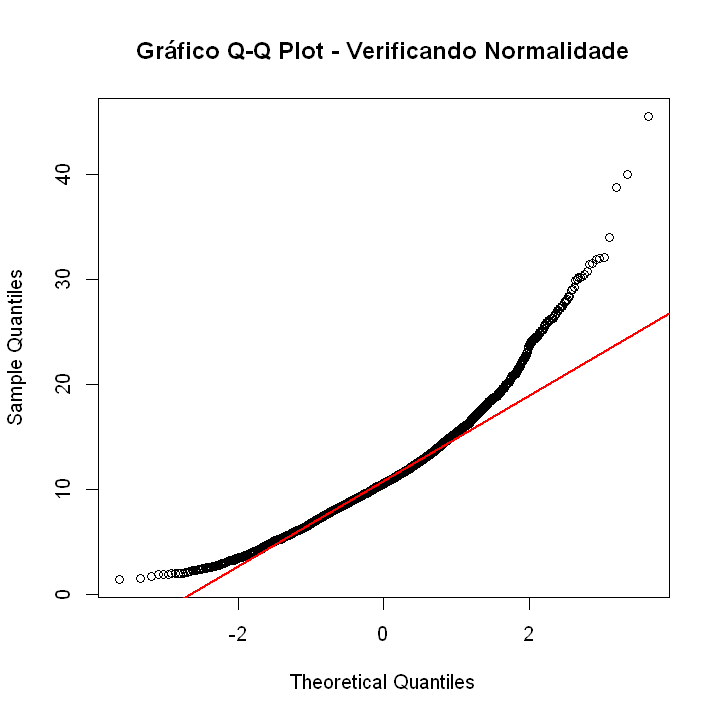

In [94]:
# 1. O PULO DO GATO: Configura o tamanho ideal (18x6) automaticamente aqui dentro!
  options(repr.plot.width = 6, repr.plot.height = 6)

# Desenha o gráfico de pontos
qqnorm(df_longevid_1$valor, main = "Gráfico Q-Q Plot - Verificando Normalidade")

# Desenha uma linha de referência ideal
qqline(df_longevid_1$valor, col = "red", lwd = 2)


In [95]:
summary(df_longevid_1$valor)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.508   8.116  10.610  11.202  13.559  45.455 

Mediana (10.76) < Média (10.82)

In [96]:
# Instalar o pacote (se já tiver, pode pular essa linha)
pacman::p_load(nortest)
# Executar Teste de Lilliefors na amostra:
lillie.test(df_longevid_1$valor)



	Lilliefors (Kolmogorov-Smirnov) normality test

data:  df_longevid_1$valor
D = 0.071559, p-value < 2.2e-16


In [97]:
# Conta quantos valores ÚNICOS e diferentes existem na sua coluna
length(unique(df_longevid_1$valor))

[1] 2599

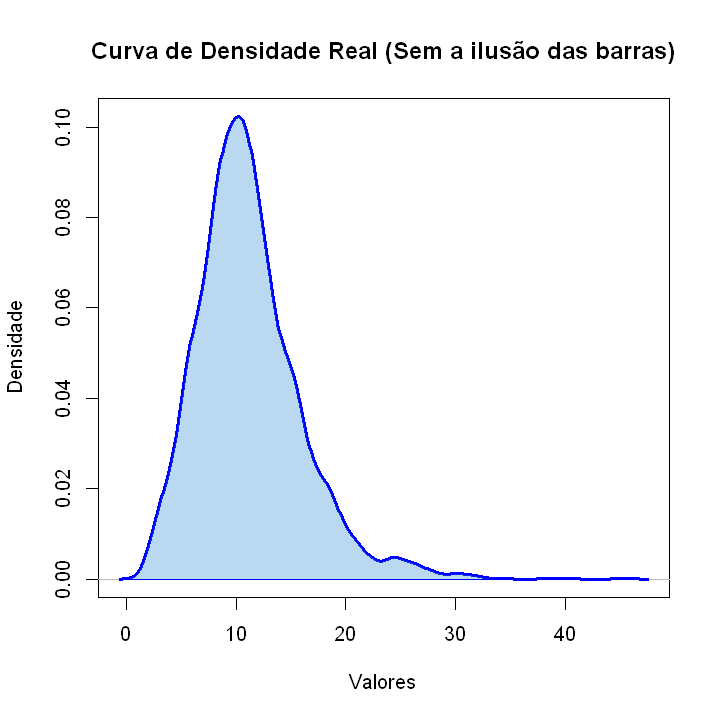

In [98]:
# 1. Calcula a linha de densidade suave
densidade <- density(df_longevid_1$valor, na.rm = TRUE)

# 2. Desenha o gráfico de linha (sem barras)
plot(densidade, 
     main = "Curva de Densidade Real (Sem a ilusão das barras)",
     col = "blue", 
     lwd = 3,
     xlab = "Valores",
     ylab = "Densidade")

# 3. Pinta a área debaixo da curva para enxergar melhor
polygon(densidade, col = rgb(0.1, 0.5, 0.8, 0.3), border = "blue")


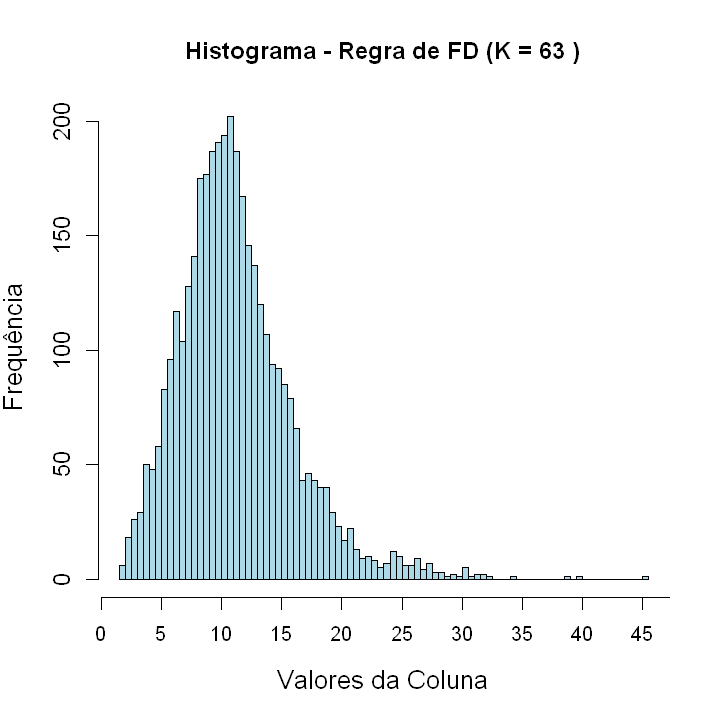

In [99]:
# 1. Criando uma "coluna" de dados de exemplo
coluna_dados <- df_longevid_1$valor

# 2. Calculando o número ideal de barras (K)

# Usando a Regra de Sturges
k_sturges <- nclass.Sturges(coluna_dados)

# Usando a Regra de Freedman-Diaconis (FD) - CORRIGIDO ✅
k_fd <- nclass.FD(coluna_dados)

# 3. Desenhando o histograma simples (Exemplo usando FD)
hist(coluna_dados, 
     breaks = k_fd,                                                # Aplica a regra de FD
     col = "lightblue",                                            # Cor das barras
     border = "#000",                                         # Cor da borda
     main = paste("Histograma - Regra de FD (K =", k_fd, ")"),     # Título
     xlab = "Valores da Coluna",                                   # Eixo X
     ylab = "Frequência",                                          # Eixo Y
     cex.lab = 1.3,
     cex.axis = 1.2,
     xaxt = 'n')    # Tirando a régua original do eixo X (mto RUIM!)                                

axis(side = 1, at = pretty(coluna_dados, n = 13))

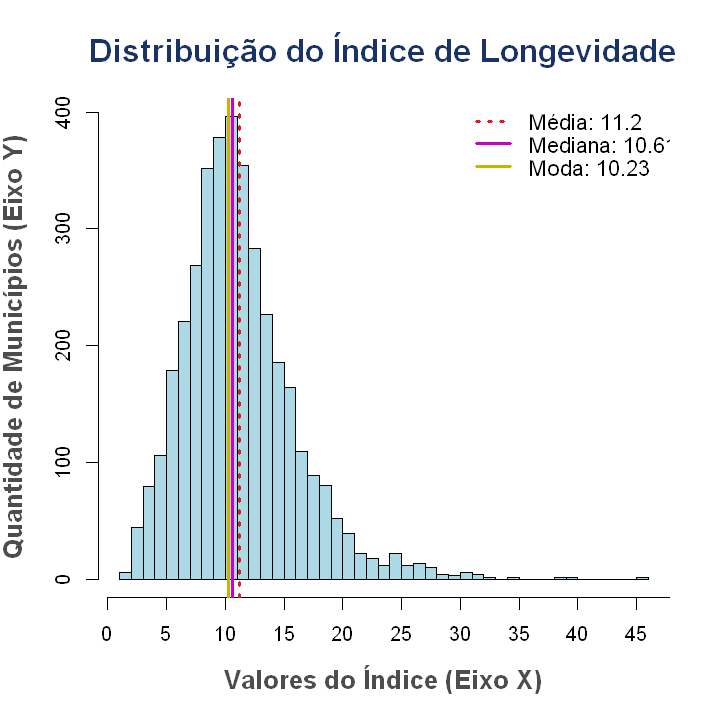

In [100]:
# 1. Dados e Cálculos
d <- df_longevid_1$valor
m_media <- mean(d, na.rm=T); m_med <- median(d, na.rm=T)
m_mod <- density(d, na.rm=T)$x[which.max(density(d, na.rm=T)$y)]

# 2. Histograma com Textos Customizados
hist(d, breaks=nclass.scott(d), col="lightblue", border="#000", xaxt='n',
     main = "Distribuição do Índice de Longevidade", 
     xlab = "Valores do Índice (Eixo X)",            
     ylab = "Quantidade de Municípios (Eixo Y)",     
     cex.main = 1.6, col.main = rgb(0.1, 0.2, 0.4), font.main = 2,
     cex.lab = 1.3, col.lab = rgb(0.3, 0.3, 0.3), font.lab = 2)

axis(1, at=pretty(d, n=12))

# 3. Linhas RGB
abline(v=m_media, col=rgb(0.9,0.1,0.1), lwd=3, lty=3)
abline(v=m_med,   col=rgb(0.8,0.0,0.8), lwd=3)
abline(v=m_mod,   col=rgb(0.8,0.7,0.0), lwd=3)

# 4. Legenda Identificada (Nomes + Valores)
legend("topright", bty="n", lwd=3, lty=c(3,1,1), cex=1.1,
       col=c(rgb(0.9,0.1,0.1), rgb(0.8,0.0,0.8), rgb(0.8,0.7,0.0)),
       legend=c(paste("Média:", round(m_media, 2)),
                paste("Mediana:", round(m_med, 2)),
                paste("Moda:", round(m_mod, 2))))


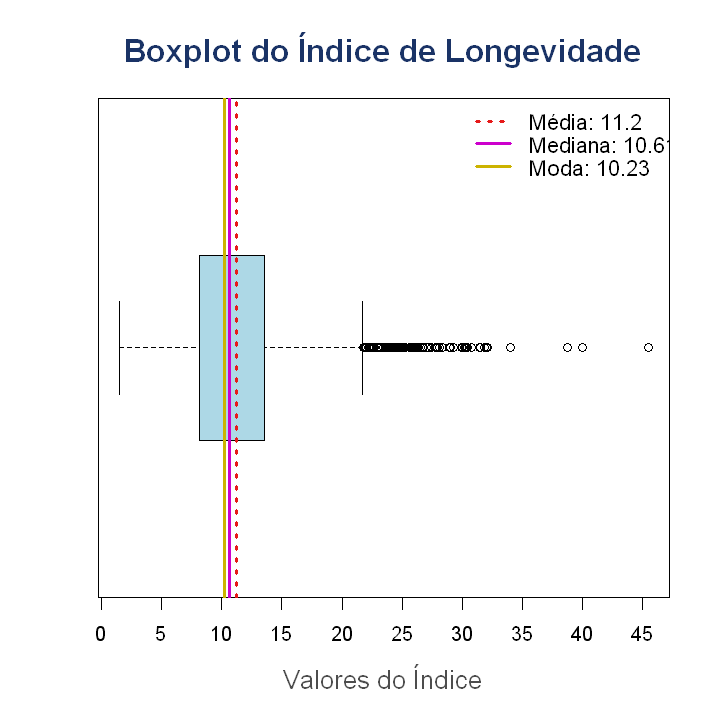

In [101]:
# 1. Dados e Cálculos (Mantendo os mesmos)
d <- df_longevid_1$valor
m_media <- mean(d, na.rm=T); m_med <- median(d, na.rm=T)
m_mod <- density(d, na.rm=T)$x[which.max(density(d, na.rm=T)$y)]

# 2. Boxplot Customizado (Mesmas cores e tamanhos do anterior)
boxplot(d, col="lightblue", border="#000", yaxt='n', horizontal=TRUE,
        main = "Boxplot do Índice de Longevidade",
        xlab = "Valores do Índice",
        cex.main = 1.6, col.main = rgb(0.1, 0.2, 0.4), font.main = 2,
        cex.lab = 1.3, col.lab = rgb(0.3, 0.3, 0.3), font.lab = 2)

# Alinha a régua dos valores no eixo horizontal (Eixo X)
axis(1, at=pretty(d, n=12))

# 3. Adicionando Média, Mediana e Moda com as linhas RGB
# Usamos 'h' para linhas horizontais que vão cruzar o boxplot de ponta a ponta
abline(v=m_media, col=rgb(0.9,0.1,0.1), lwd=3, lty=3) # Média Pontilhada
abline(v=m_med,   col=rgb(0.8,0.0,0.8), lwd=3)       # Mediana
abline(v=m_mod,   col=rgb(0.8,0.7,0.0), lwd=3)       # Moda

# 4. Legenda Identificada
legend("topright", bty="n", lwd=3, lty=c(3,1,1), cex=1.1,
       col=c(rgb(0.9,0.1,0.1), rgb(0.8,0.0,0.8), rgb(0.8,0.7,0.0)),
       legend=c(paste("Média:", round(m_media, 2)),
                paste("Mediana:", round(m_med, 2)),
                paste("Moda:", round(m_mod, 2))))


In [102]:
plot_longevidade <- function(dados, titulo_principal = "Análise de Longevidade") {
  # 0. Configura o tamanho da imagem no VS Code / Jupyter (Largura = 18, Altura = 6)
  options(repr.plot.width = 18, repr.plot.height = 6)

  # 1. Configura a tela para 1 linha e 2 colunas (Subplots lado a lado)
  par(mfrow = c(1, 2))
  
  # 2. Cálculos das Medidas de Centro
  m_media <- mean(dados, na.rm=T)
  m_med   <- median(dados, na.rm=T)
  m_mod   <- density(dados, na.rm=T)$x[which.max(density(dados, na.rm=T)$y)]
  
  # Definição padrão de cores RGB
  c_red <- rgb(0.9,0.1,0.1); c_mag <- rgb(0.8,0.0,0.8); c_yel <- rgb(0.8,0.7,0.0)
  
  # ==========================================
  # SUBPLOT 1: HISTOGRAMA
  # ==========================================
  hist(dados, breaks=nclass.scott(dados), col="lightblue", border="#000", xaxt='n',
       main = paste(titulo_principal, "(Hist)"), 
       xlab = "Valores do Índice", ylab = "Frequência",     
       cex.main = 1.4, col.main = rgb(0.1, 0.2, 0.4), font.main = 2,
       cex.lab = 1.2, col.lab = rgb(0.3, 0.3, 0.3), font.lab = 2)
  
  axis(1, at=pretty(dados, n=10))
  abline(v=c(m_media, m_med, m_mod), col=c(c_red, c_mag, c_yel), lwd=3, lty=c(3,1,1))
  
  legend("topright", bty="n", lwd=3, lty=c(3,1,1), cex=0.9, col=c(c_red, c_mag, c_yel),
         legend=c(paste("Média:", round(m_media, 2)),
                  paste("Mediana:", round(m_med, 2)),
                  paste("Moda:", round(m_mod, 2))))
  
  # ==========================================
  # SUBPLOT 2: BOXPLOT
  # ==========================================
  boxplot(dados, col="lightblue", border="#000", yaxt='n', horizontal=TRUE,
          main = paste(titulo_principal, "(Boxplot)"), xlab = "Valores do Índice",
          cex.main = 1.4, col.main = rgb(0.1, 0.2, 0.4), font.main = 2,
          cex.lab = 1.2, col.lab = rgb(0.3, 0.3, 0.3), font.lab = 2)
  
  axis(1, at=pretty(dados, n=10))
  abline(v=c(m_media, m_med, m_mod), col=c(c_red, c_mag, c_yel), lwd=3, lty=c(3,1,1))
  
  legend("topright", bty="n", lwd=3, lty=c(3,1,1), cex=0.9, col=c(c_red, c_mag, c_yel),
         legend=c(paste("Média:", round(m_media, 2)),
                  paste("Mediana:", round(m_med, 2)),
                  paste("Moda:", round(m_mod, 2))))
  
  # 3. Reseta a tela do R de volta para 1 gráfico por vez após terminar
  par(mfrow = c(1, 1))
}


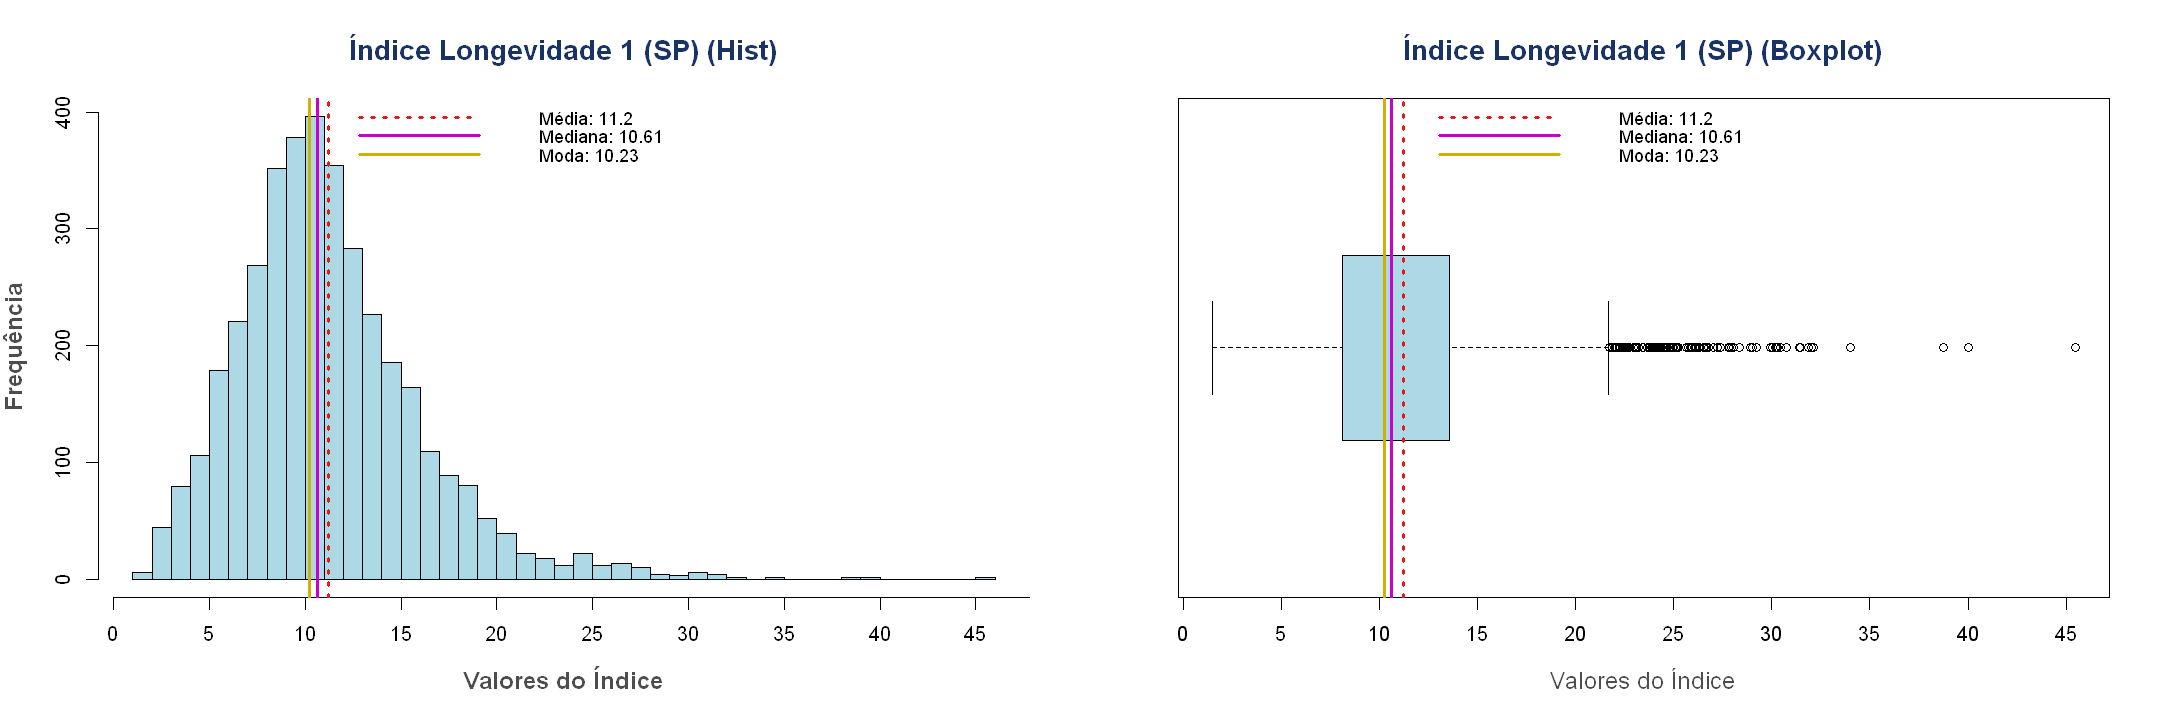

In [103]:
# # 1. Configura o tamanho da imagem no VS Code / Jupyter (Largura = 18, Altura = 6)
# options(repr.plot.width = 18, repr.plot.height = 6)

# 2. Chama a função que criamos para desenhar os gráficos lado a lado
plot_longevidade(df_longevid_1$valor, titulo_principal = "Índice Longevidade 1 (SP)")


### **Análise definitiva (EDA) a respeito da distribuição estadual de indicadores de desenvolvimento:**

- Ressalvas:
    - Como os registros das cidades das Baixada fazem parte dos registros estaduais achei melhor *não remove-los* por enquanto.
    - Futuramente fazer a **comparação entre a distribuição Estadual e a da Baixada** .
    - Códigos abaixo são ordenados de maneira mais eficiente no sentido de **modularização de código**.

#### **1) Pegando CSVs das 12 variáveis de desenvolv. Regional:**

In [104]:
get_sub_dataset <- function(df_name) {
    df_ <- read.csv(
        paste0(PATH_FOLDER, df_name), 
            fileEncoding = "UTF-8")
    return (df_)
}

In [105]:
viewSomeRows <- function(
    df_name = '1_medida_longevi_1.csv', n_rows = 2) {
    View(head(df_name, n_rows))
}

In [106]:
df_1 <- get_sub_dataset('1_medida_longevi_1.csv')
df_2 <- get_sub_dataset('2_medida_longevi_2.csv')
df_3 <- get_sub_dataset('3_medida_longevi_3.csv')
df_4 <- get_sub_dataset('4_medida_longevi_4.csv')

df_5 <- get_sub_dataset('5_medida_escolari_1.csv')
df_6 <- get_sub_dataset('6_medida_escolari_2.csv')
df_7 <- get_sub_dataset('7_medida_escolari_3.csv')
df_8 <- get_sub_dataset('8_medida_escolari_4.csv')

df_9 <- get_sub_dataset('9_medida_economia_1.csv')
df_10 <- get_sub_dataset('10_medida_economia_2.csv')
df_11 <- get_sub_dataset('11_medida_consumo_1.csv')
df_12 <- get_sub_dataset('12_medida_consumo_2.csv')

#### **2) Checagem de Normalizade nos 12 indicadores:**

Não estou removendo **outlires** pois isso diz a todas as cidades do Estado. Tenho **intenção de
comparar indice estual total** com indice da **baixada santista**:

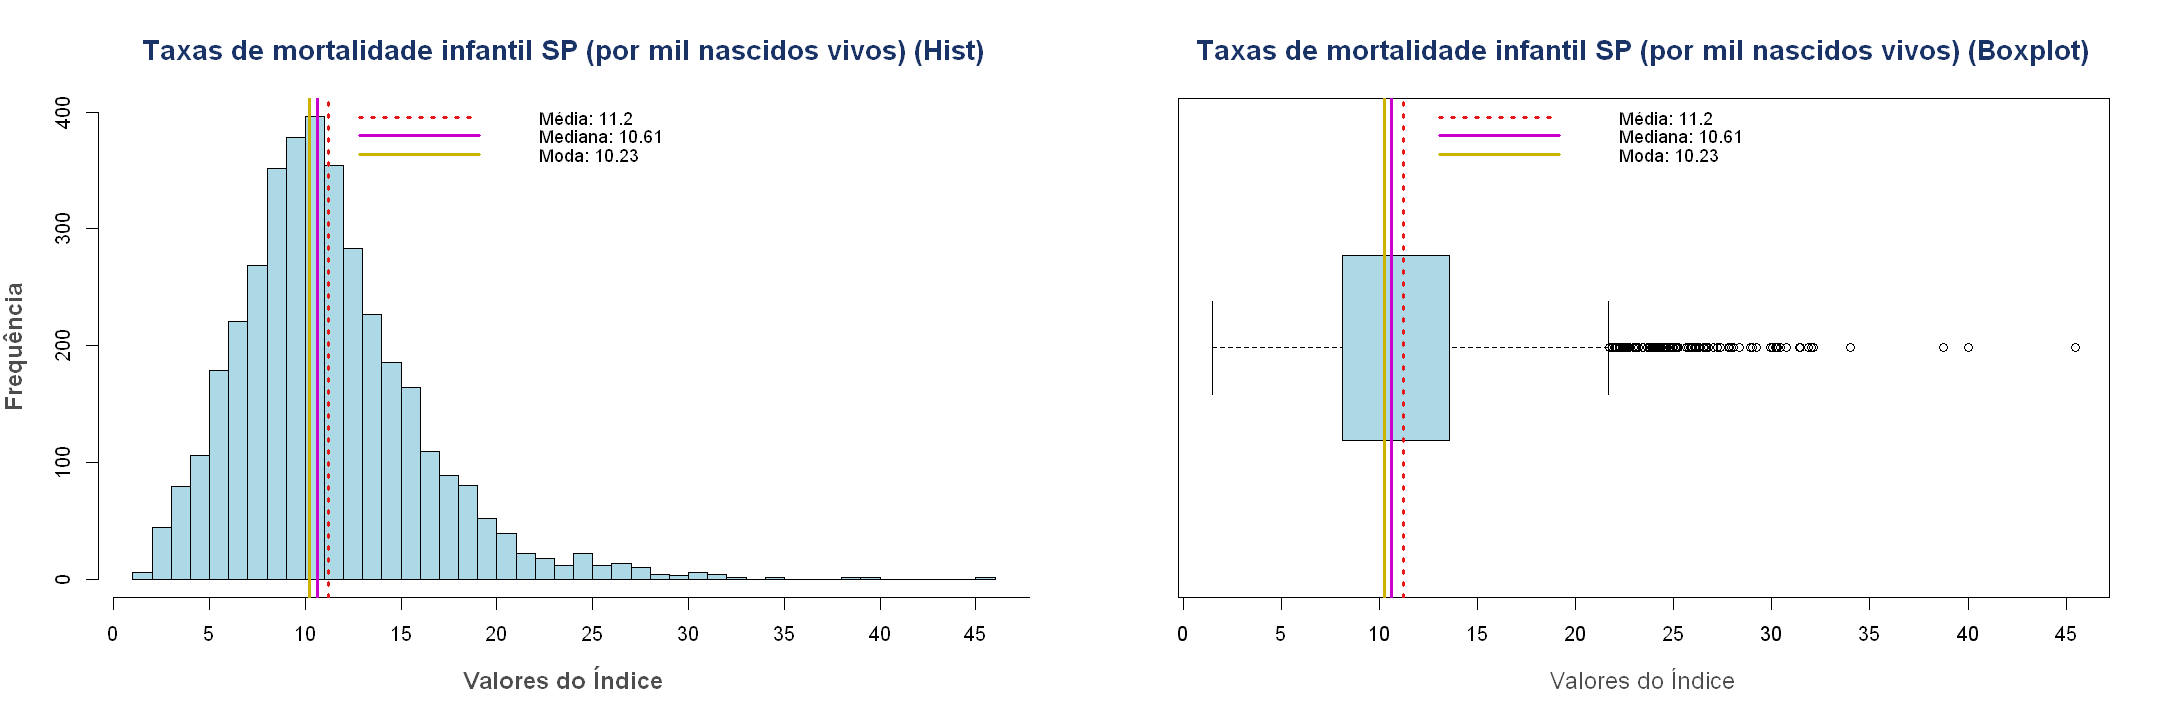

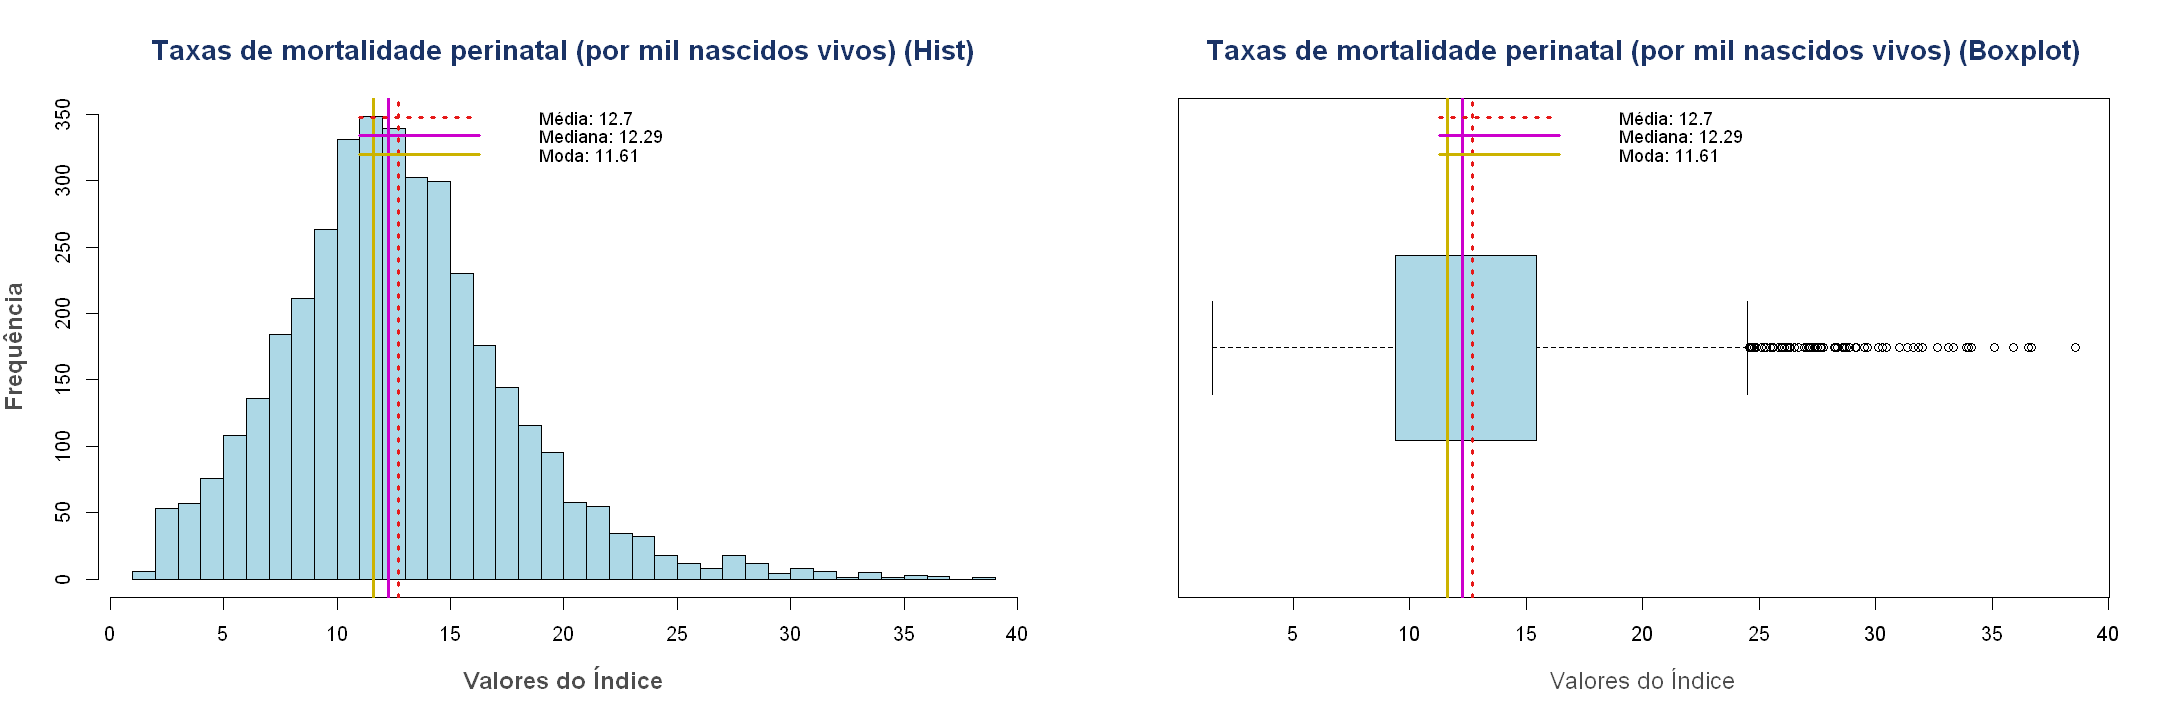

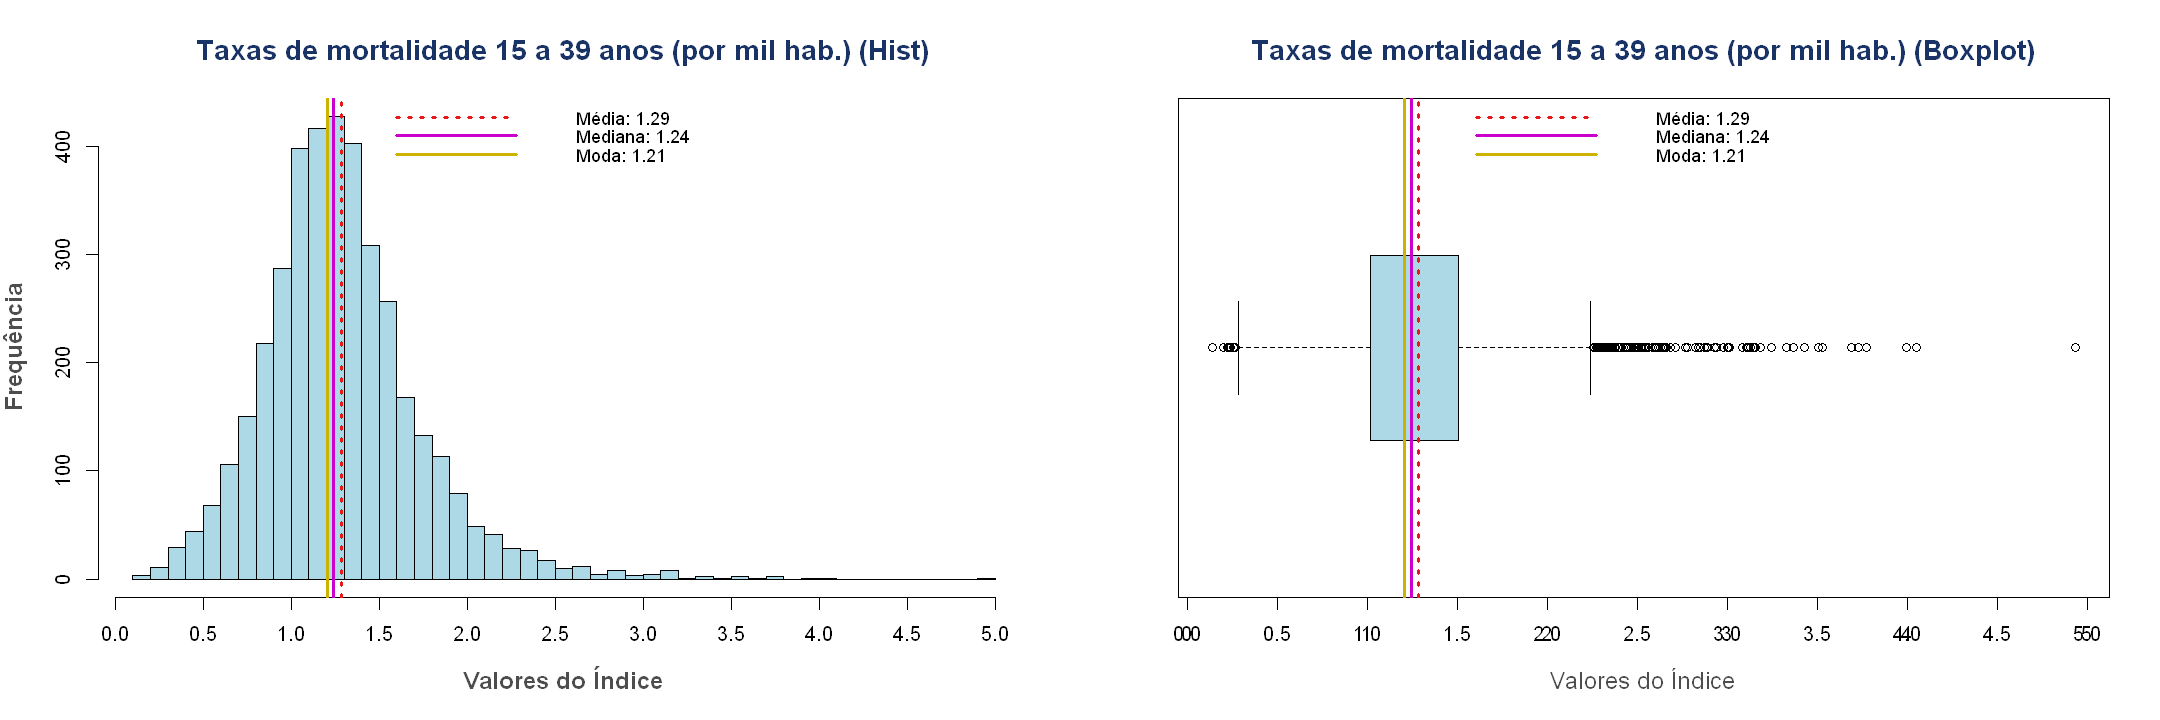

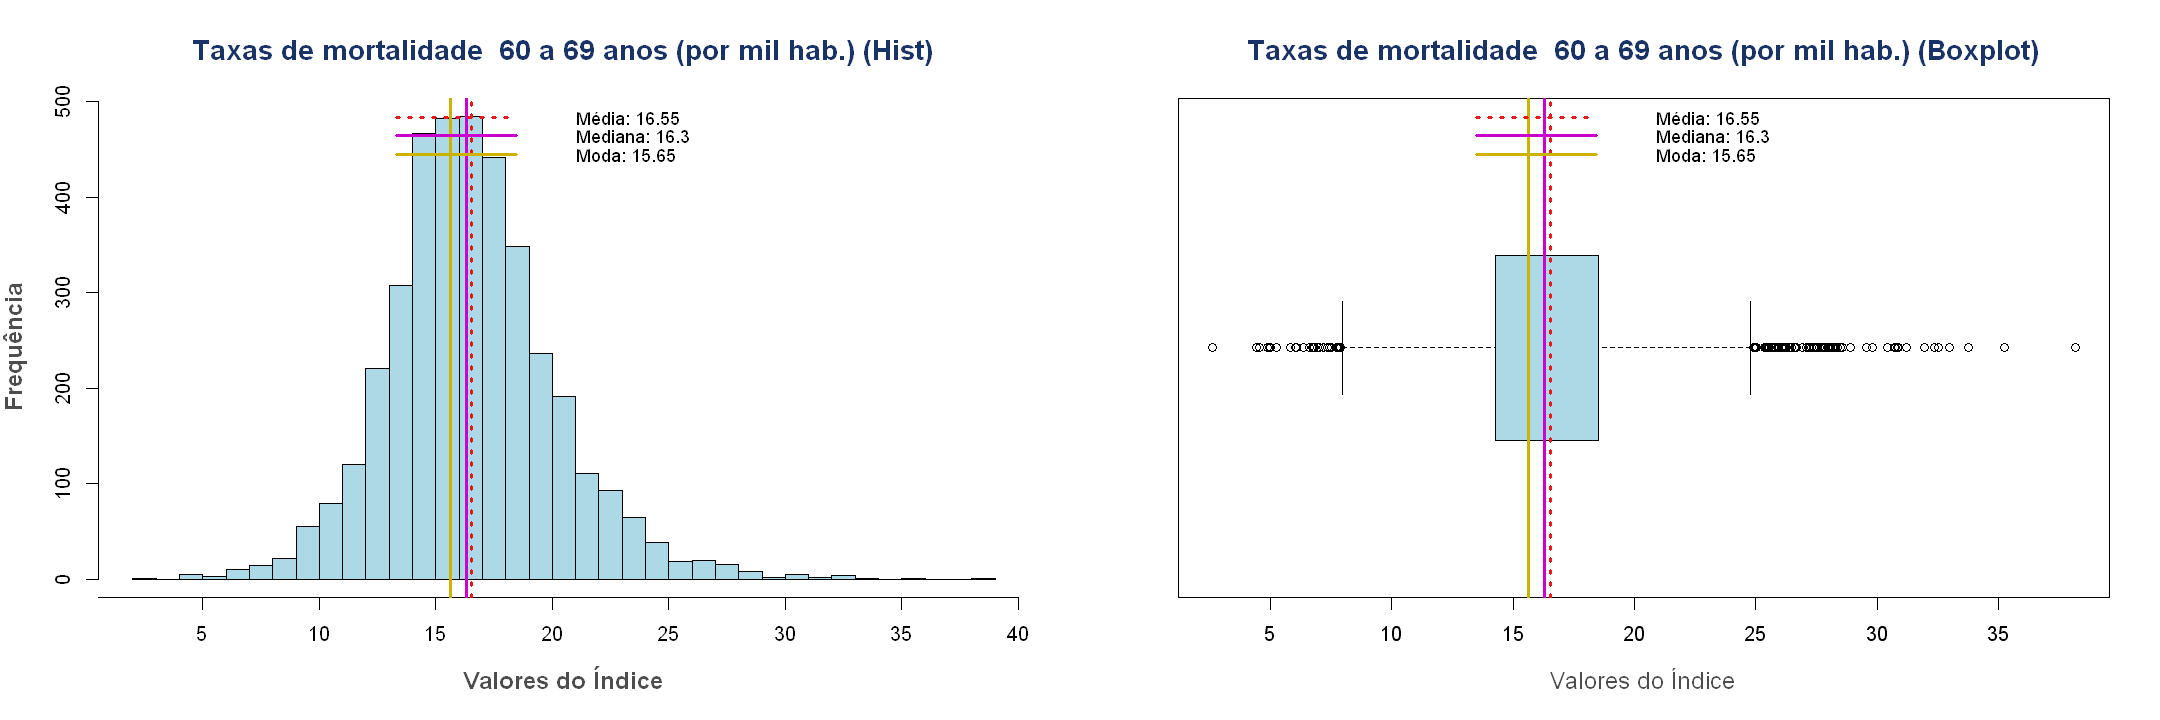

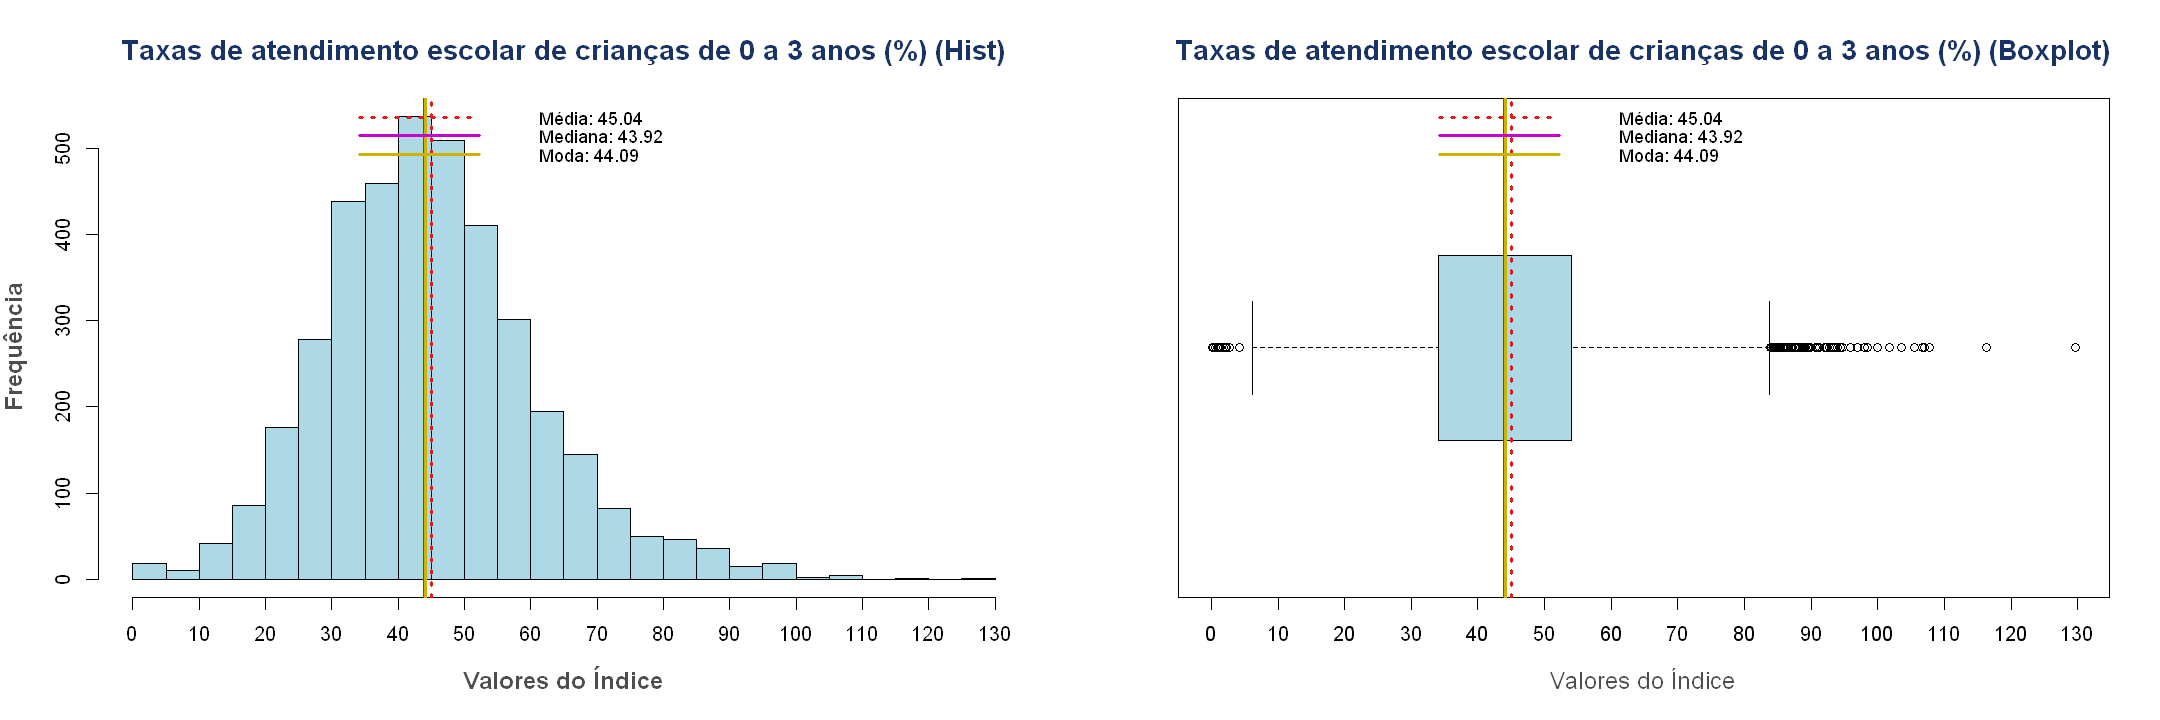

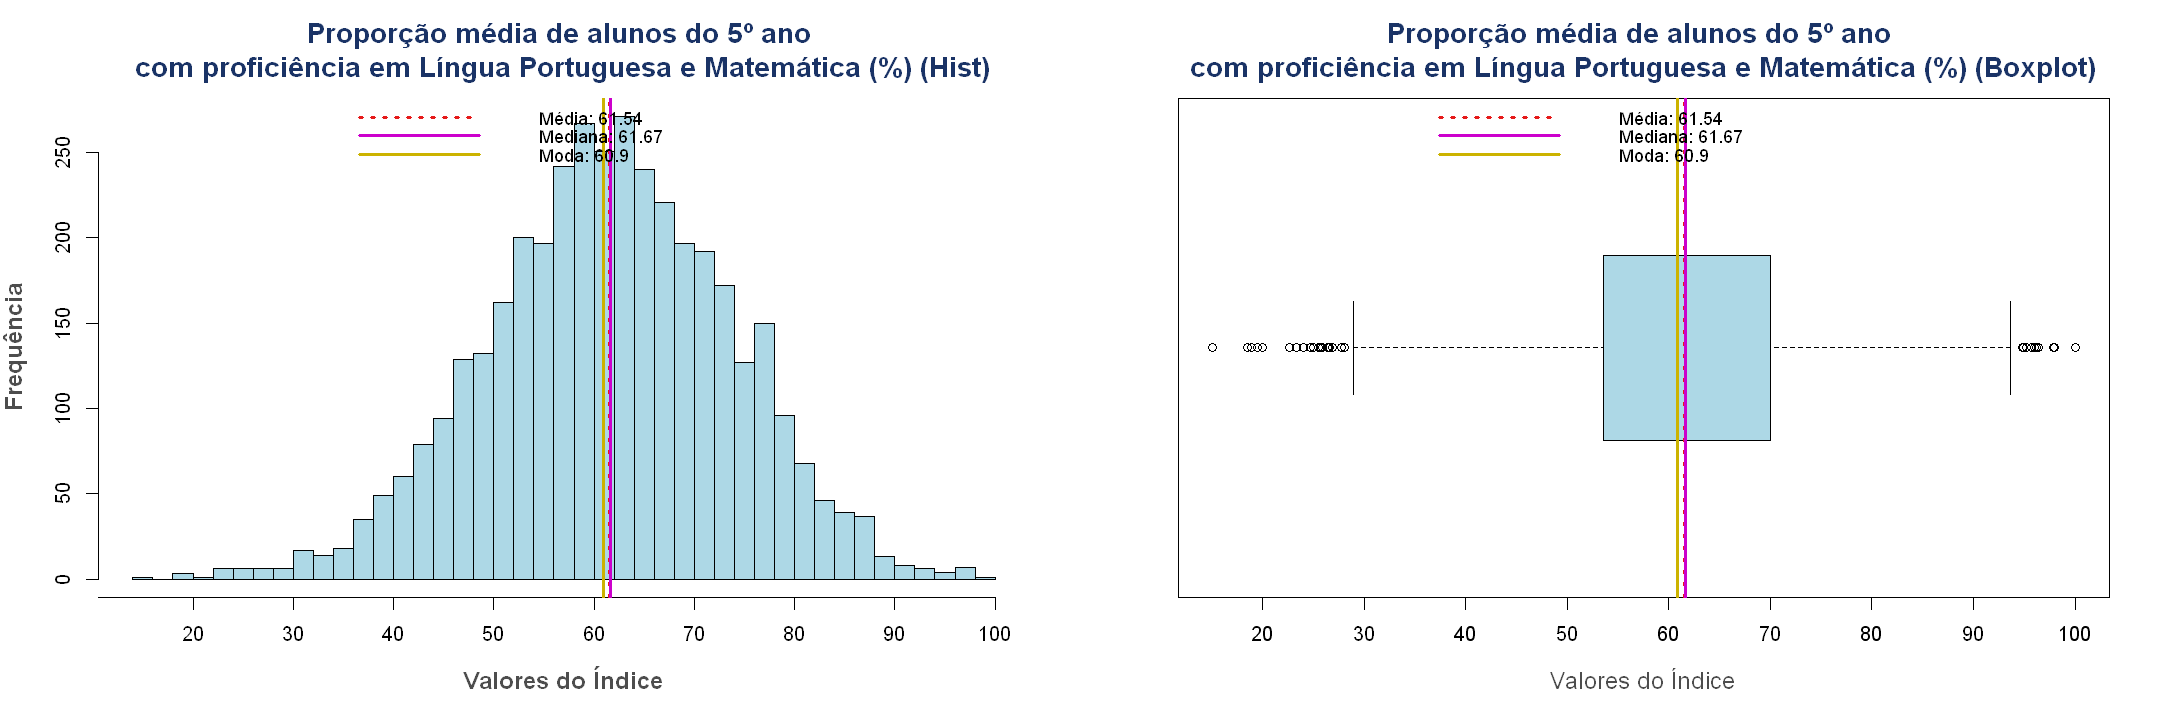

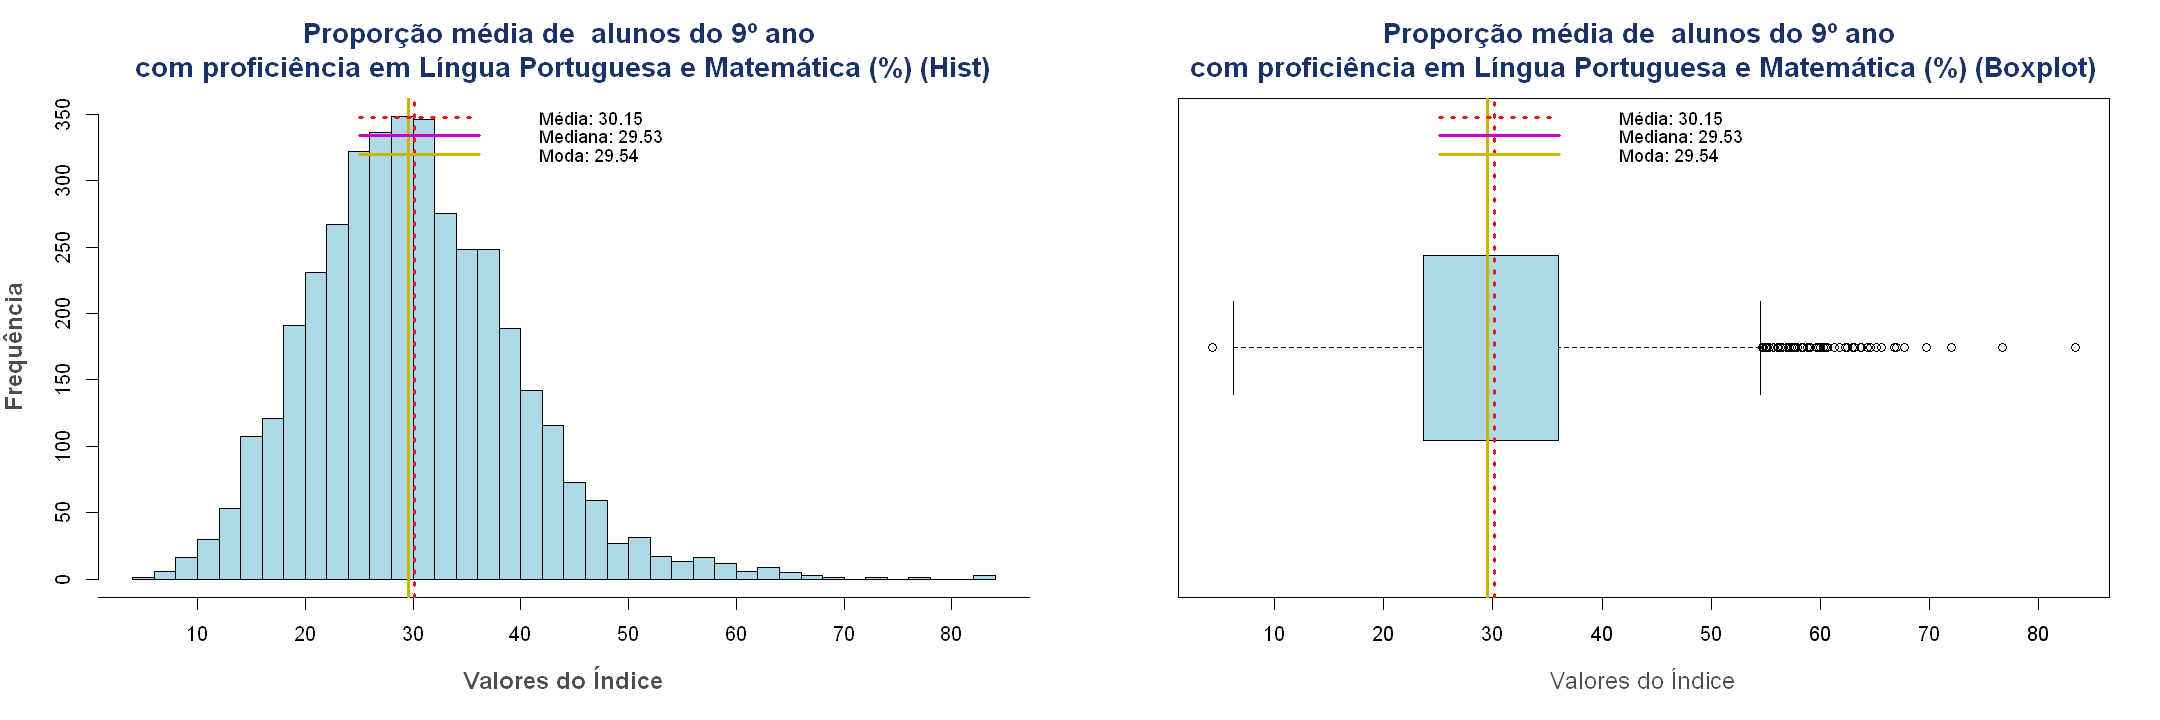

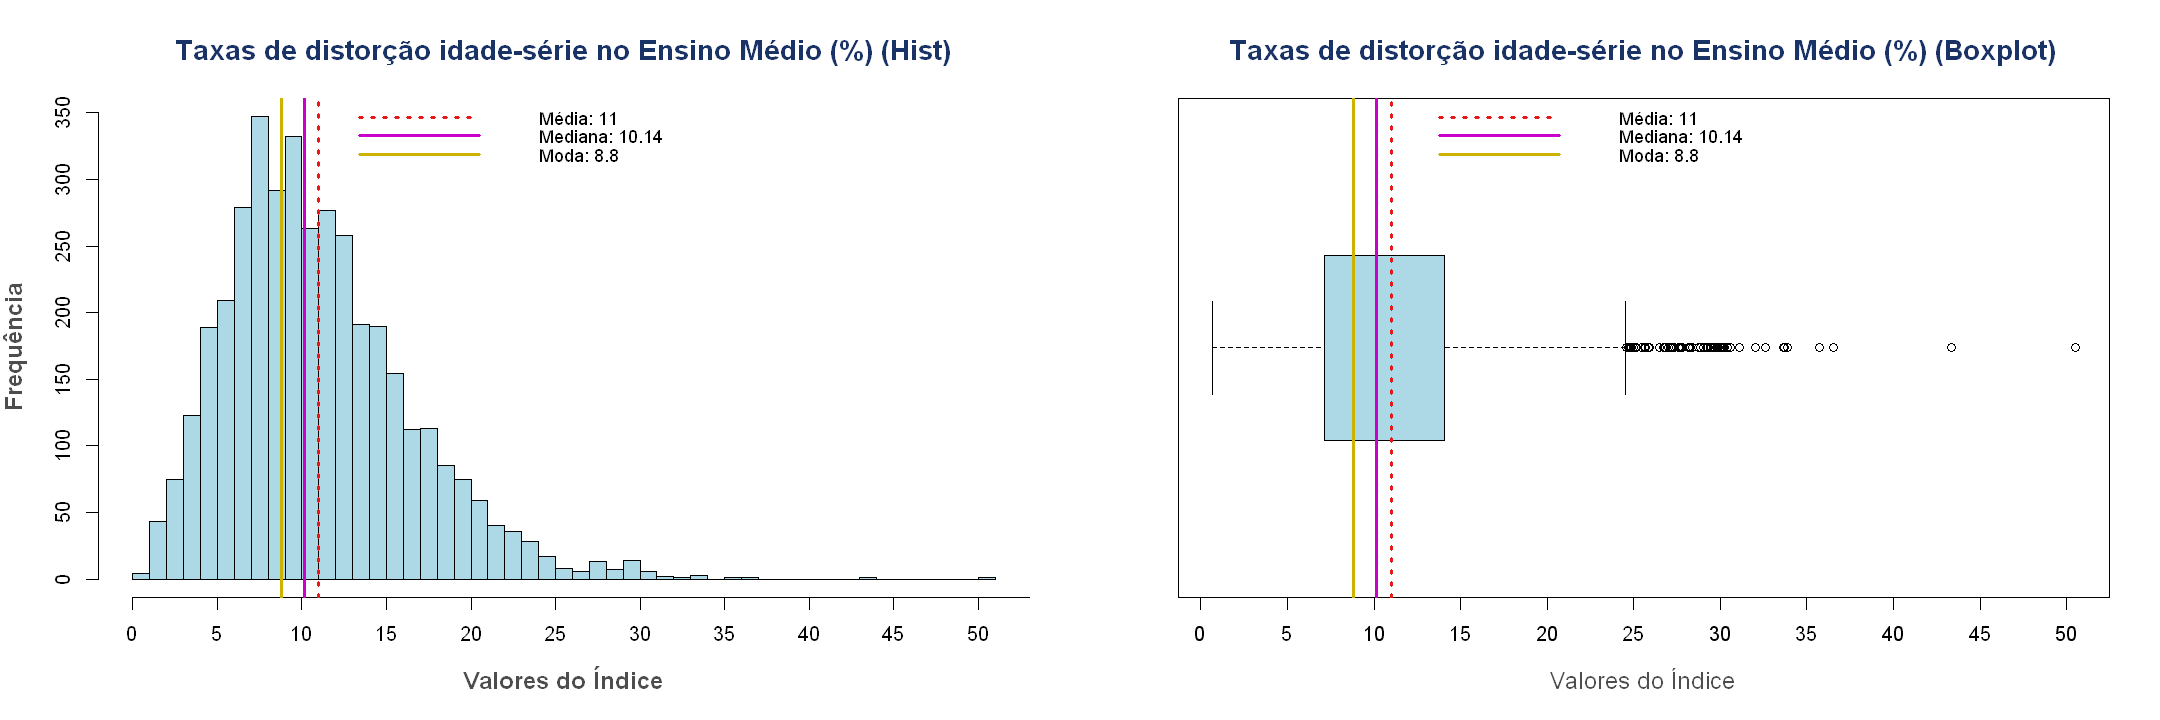

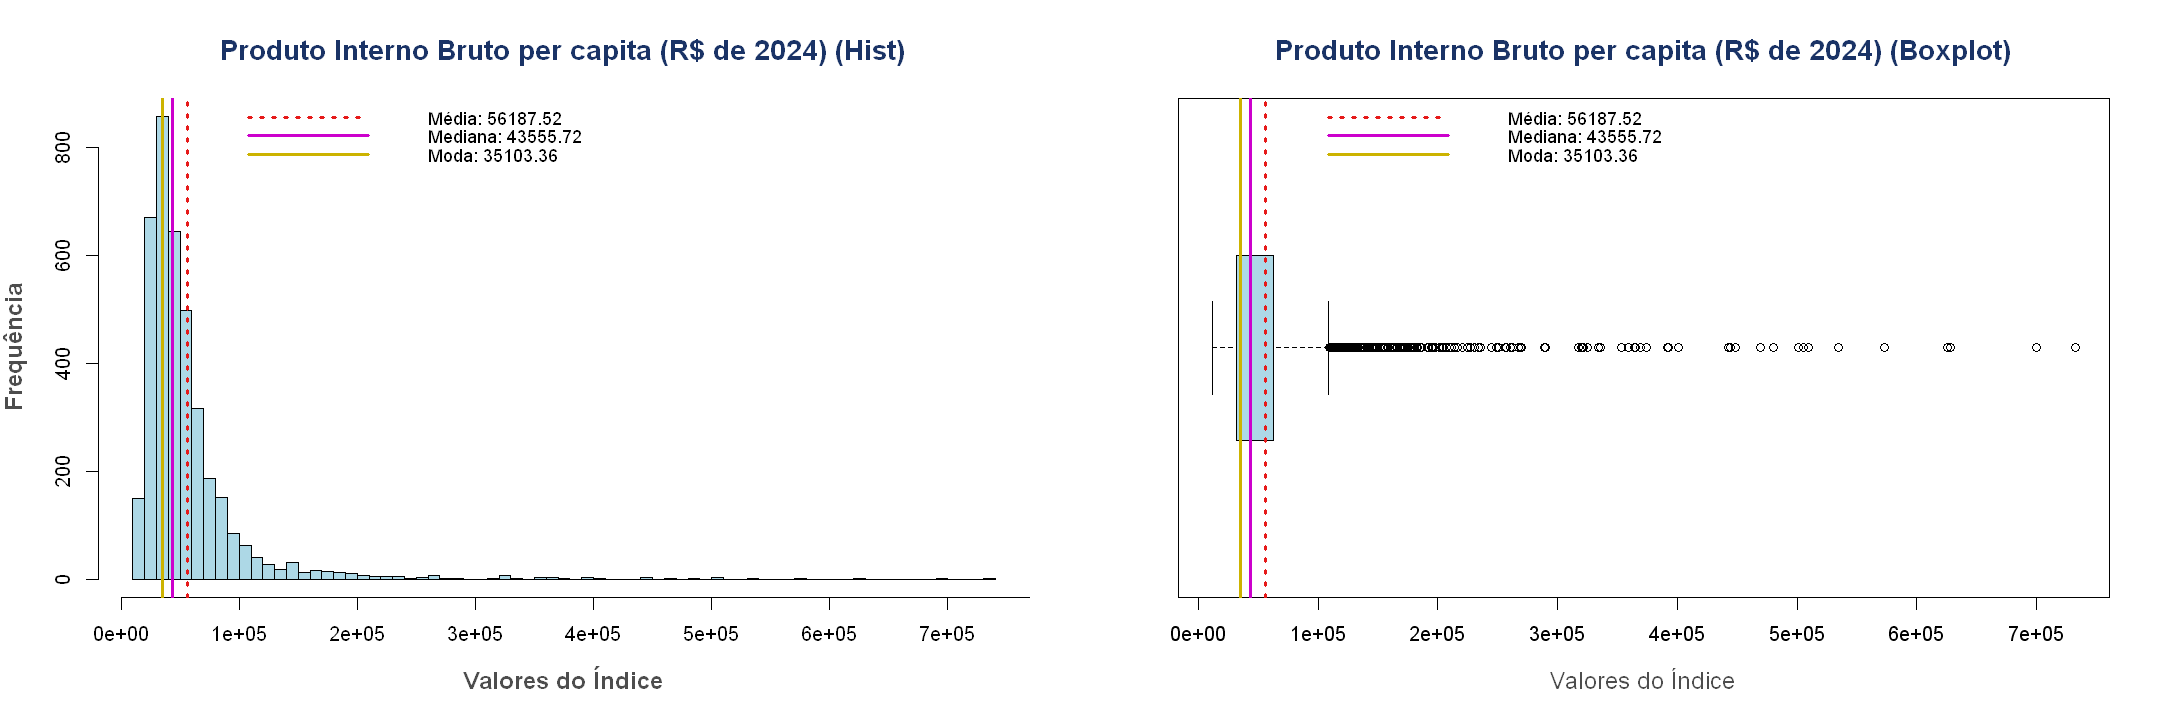

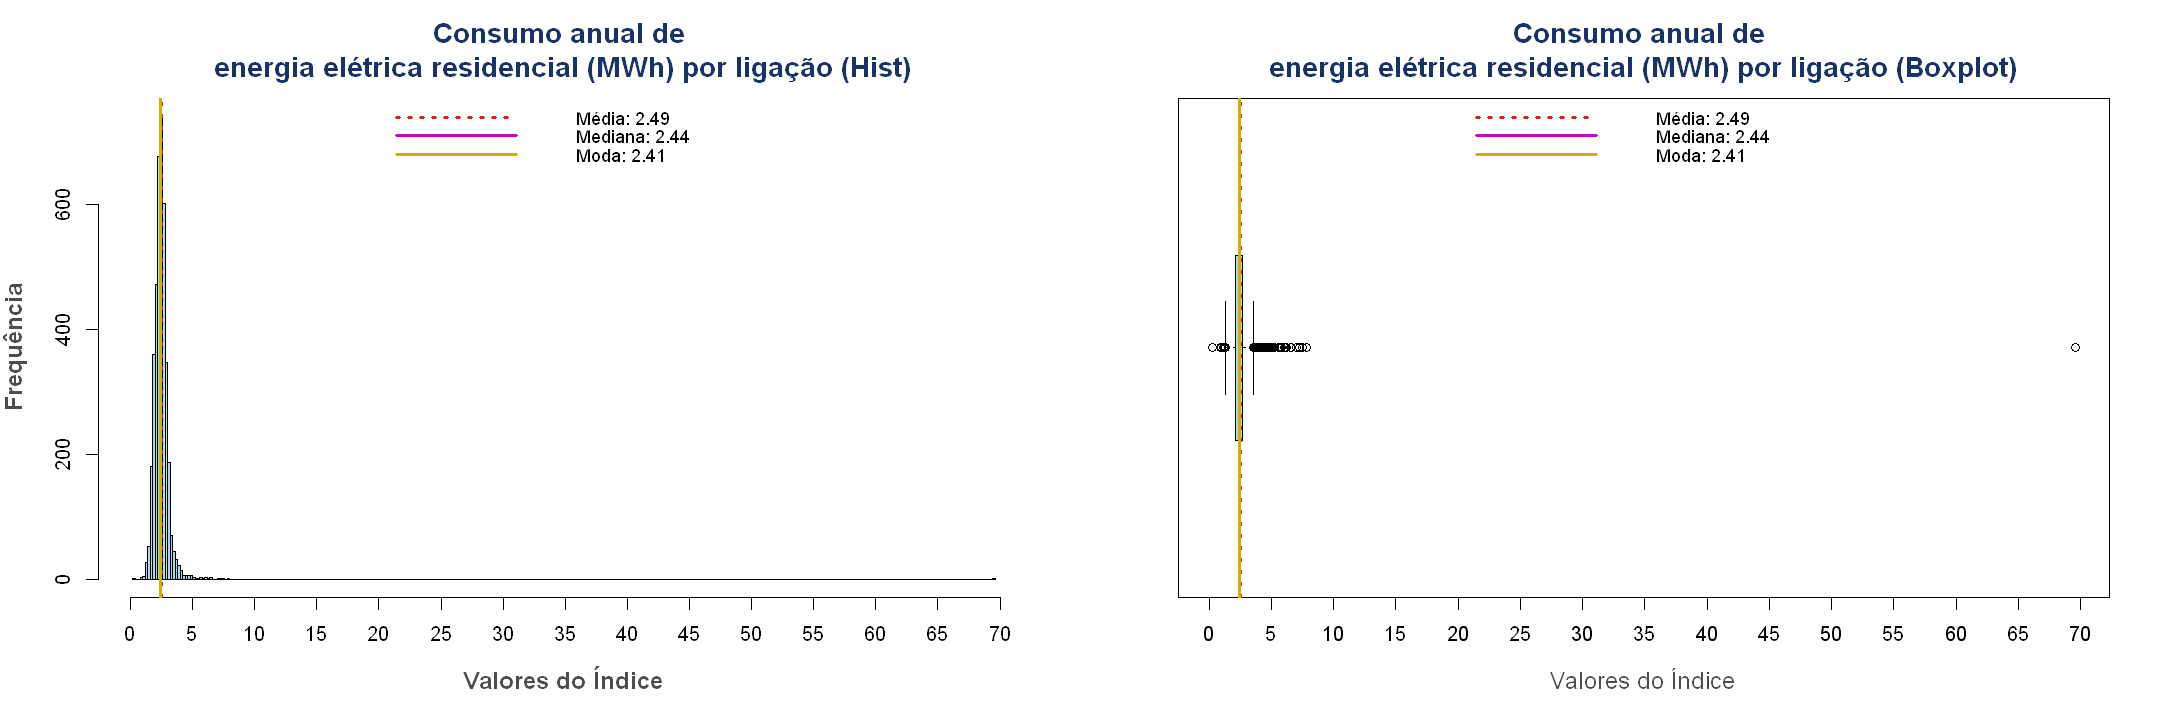

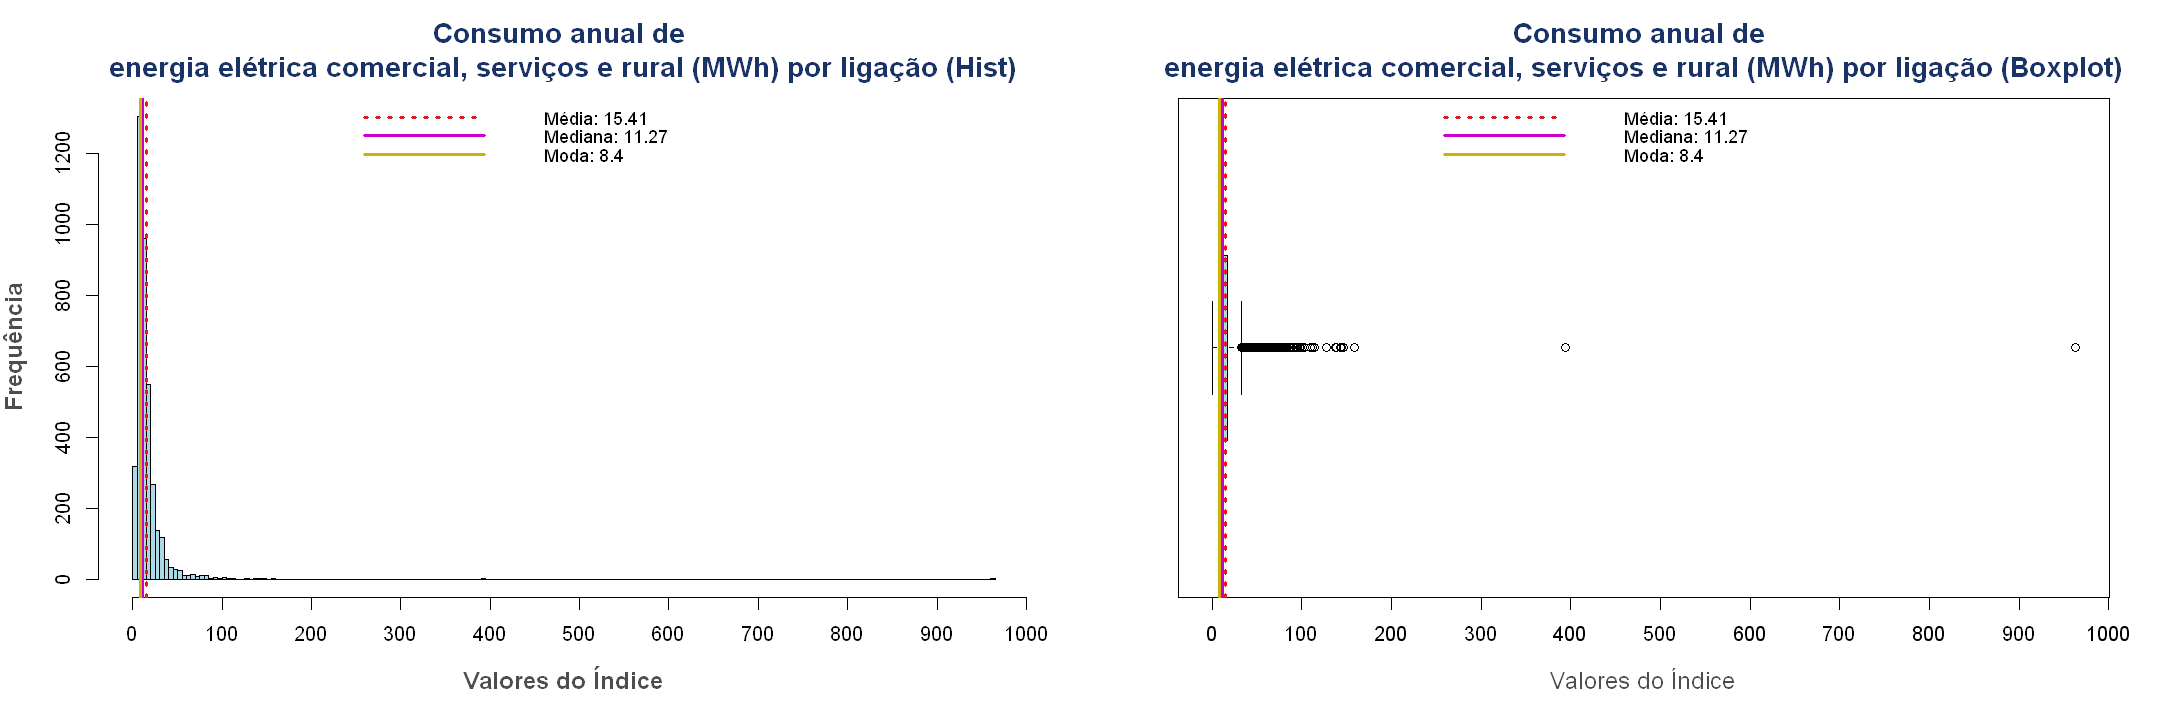

In [107]:
plot_longevidade(df_1$valor, titulo_principal = "Taxas de mortalidade infantil SP (por mil nascidos vivos)")
plot_longevidade(df_2$valor, titulo_principal = "Taxas de mortalidade perinatal (por mil nascidos vivos)")
plot_longevidade(df_3$valor, titulo_principal = "Taxas de mortalidade 15 a 39 anos (por mil hab.)")
plot_longevidade(df_4$valor, titulo_principal = "Taxas de mortalidade  60 a 69 anos (por mil hab.)")

plot_longevidade(df_5$valor, titulo_principal = "Taxas de atendimento escolar de crianças de 0 a 3 anos (%)")
plot_longevidade(df_6$valor, titulo_principal = "Proporção média de alunos do 5º ano \ncom proficiência em Língua Portuguesa e Matemática (%)")
plot_longevidade(df_7$valor, titulo_principal = "Proporção média de  alunos do 9º ano \ncom proficiência em Língua Portuguesa e Matemática (%)")
plot_longevidade(df_8$valor, titulo_principal = "Taxas de distorção idade-série no Ensino Médio (%)")

plot_longevidade(df_9$valor, titulo_principal = "Produto Interno Bruto per capita (R$ de 2024)")     # DataFrame de origem 9 está igual ao 10 (checar pq depois!!!!)
# # plot_longevidade(df_10$valor, titulo_principal = "Produto Interno Bruto per capita (R$ de 2024)")  # Irrelevante mostrar ... CORRIGIR >>>DEPOIS<<<

plot_longevidade(df_11$valor, titulo_principal = "Consumo anual de \nenergia elétrica residencial (MWh) por ligação")
plot_longevidade(df_12$valor, titulo_principal = "Consumo anual de \nenergia elétrica comercial, serviços e rural (MWh) por ligação")